In [ ]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import os

DRIVE_ROOT = Path(
    "/content/drive/MyDrive/OceanEmbeDeTrainingData"
)

print("Data directory exists:",
      DRIVE_ROOT.exists())

if DRIVE_ROOT.exists():
    for f in sorted(DRIVE_ROOT.glob("modelready_*.nc")):
        print(
            f.name,
            round(f.stat().st_size / 1024**2, 1),
            "MB"
        )

Mounted at /content/drive
Data directory exists: True
modelready_2000.nc 303.6 MB
modelready_2001.nc 298.8 MB
modelready_2002.nc 295.8 MB
modelready_2003.nc 298.4 MB
modelready_2004.nc 298.1 MB
modelready_2005.nc 292.3 MB


In [ ]:
import shutil

LOCAL_ROOT = Path(
    "/content/OceanEmbeDeTrainingData"
)

if not LOCAL_ROOT.exists():

    print("Copying data from Drive...")

    shutil.copytree(
        DRIVE_ROOT,
        LOCAL_ROOT
    )

else:

    print("Local data already exists.")

print("\nLocal files:")

for f in sorted(LOCAL_ROOT.glob("modelready_*.nc")):
    print(
        f.name,
        round(f.stat().st_size / 1024**2, 1),
        "MB"
    )

Copying data from Drive...

Local files:
modelready_2000.nc 303.6 MB
modelready_2001.nc 298.8 MB
modelready_2002.nc 295.8 MB
modelready_2003.nc 298.4 MB
modelready_2004.nc 298.1 MB
modelready_2005.nc 292.3 MB


In [ ]:
import torch

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", DEVICE)

if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

    print(
        "VRAM:",
        round(
            torch.cuda.get_device_properties(0)
            .total_memory / 1024**3,
            2
        ),
        "GB"
    )

Device: cuda
GPU: Tesla T4
VRAM: 14.56 GB


In [ ]:
import torch.nn as nn


class OceanEmbedNet(nn.Module):

    def __init__(
        self,
        in_channels=14,
        embedding_dim=64,
        out_channels=14
    ):

        super().__init__()

        # --------------------------------------------
        # CNN ENCODER
        # --------------------------------------------

        self.encoder = nn.Sequential(

            nn.Conv2d(
                in_channels,
                32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                64,
                64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )

        # --------------------------------------------
        # TEMPORAL GRU
        # --------------------------------------------

        self.gru = nn.GRU(
            input_size=64,
            hidden_size=64,
            num_layers=1,
            batch_first=True
        )

        # --------------------------------------------
        # CHANNEL ATTENTION
        # --------------------------------------------

        self.attention_pool = nn.AdaptiveAvgPool2d(1)

        self.attention = nn.Sequential(

            nn.Linear(64, 16),
            nn.ReLU(inplace=True),

            nn.Linear(16, 64),
            nn.Sigmoid()
        )

        # --------------------------------------------
        # DECODER
        # --------------------------------------------

        self.decoder = nn.Sequential(

            nn.Conv2d(
                64,
                64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                64,
                32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                32,
                out_channels,
                kernel_size=1
            )
        )


    def forward(
        self,
        x,
        return_embedding=False
    ):

        # x:
        # [B, T, C, H, W]

        B, T, C, H, W = x.shape

        encoded = []

        # --------------------------------------------
        # SPATIAL ENCODING
        # --------------------------------------------

        for t in range(T):

            z = self.encoder(
                x[:, t]
            )

            encoded.append(z)

        # [B,T,64,H,W]

        encoded = torch.stack(
            encoded,
            dim=1
        )

        # --------------------------------------------
        # TEMPORAL GRU
        # --------------------------------------------

        # spatial position-wise sequence

        gru_input = encoded.permute(
            0, 3, 4, 1, 2
        )

        gru_input = gru_input.reshape(
            B * H * W,
            T,
            64
        )

        gru_output, _ = self.gru(
            gru_input
        )

        z = gru_output[:, -1]

        z = z.reshape(
            B,
            H,
            W,
            64
        )

        z = z.permute(
            0, 3, 1, 2
        )

        # --------------------------------------------
        # CHANNEL ATTENTION
        # --------------------------------------------

        pooled = self.attention_pool(z)

        pooled = pooled.reshape(
            B,
            64
        )

        weights = self.attention(
            pooled
        )

        weights = weights.reshape(
            B,
            64,
            1,
            1
        )

        z = z * weights

        embedding = z

        # --------------------------------------------
        # DECODER
        # --------------------------------------------

        output = self.decoder(z)

        if return_embedding:

            return output, embedding

        return output

In [ ]:
model = OceanEmbedNet(
    in_channels=14,
    embedding_dim=64,
    out_channels=14
).to(DEVICE)

print(
    "Parameters:",
    sum(
        p.numel()
        for p in model.parameters()
    )
)

Parameters: 142942


In [ ]:
import numpy as np
import xarray as xr
import torch
from torch.utils.data import Dataset


class OceanYearDataset(Dataset):

    def __init__(
        self,
        year,
        data_root,
        patch_size=32,
        patch_stride=32,
        sequence_length=3
    ):

        self.year = year

        self.patch_size = patch_size
        self.patch_stride = patch_stride
        self.sequence_length = sequence_length

        path = (
            data_root /
            f"modelready_{year}.nc"
        )

        print(
            f"\nLoading {year}: {path}"
        )

        ds = xr.open_dataset(
            path,
            engine="h5netcdf"
        )

        surface_vars = [
            "sst",
            "sss",
            "sla",
            "uo",
            "vo",
            "wind_u",
            "wind_v"
        ]

        mask_vars = [
            "sst_mask",
            "sss_mask",
            "sla_mask",
            "uo_mask",
            "vo_mask",
            "wind_u_mask",
            "wind_v_mask"
        ]

        # --------------------------------------------
        # INPUT
        # --------------------------------------------

        surface = np.stack(
            [
                ds[v].values.astype(
                    np.float32
                )
                for v in surface_vars
            ],
            axis=1
        )

        masks = np.stack(
            [
                ds[v].values.astype(
                    np.float32
                )
                for v in mask_vars
            ],
            axis=1
        )

        self.X = np.concatenate(
            [
                surface,
                masks
            ],
            axis=1
        )

        # --------------------------------------------
        # TARGET
        # --------------------------------------------

        self.Y = ds[
            "thetao"
        ].values.astype(
            np.float32
        )

        self.M = ds[
            "thetao_mask"
        ].values.astype(
            np.float32
        )

        ds.close()

        # --------------------------------------------
        # REMOVE ONLY INVALID TARGET NaNs
        # --------------------------------------------

        self.Y = np.nan_to_num(
            self.Y,
            nan=0.0,
            posinf=0.0,
            neginf=0.0
        )

        print(
            "X:",
            self.X.shape
        )

        print(
            "Y:",
            self.Y.shape
        )

        print(
            "M:",
            self.M.shape
        )

        print(
            "RAM:",
            round(
                (
                    self.X.nbytes
                    + self.Y.nbytes
                    + self.M.nbytes
                ) / 1024**3,
                2
            ),
            "GB"
        )

        # --------------------------------------------
        # SAMPLE INDEX
        # --------------------------------------------

        ntime = self.X.shape[0]

        nlat = self.X.shape[2]

        nlon = self.X.shape[3]

        self.samples = []

        for t in range(
            sequence_length - 1,
            ntime
        ):

            for lat in range(
                0,
                nlat - patch_size + 1,
                patch_stride
            ):

                for lon in range(
                    0,
                    nlon - patch_size + 1,
                    patch_stride
                ):

                    self.samples.append(
                        (
                            t,
                            lat,
                            lon
                        )
                    )

        print(
            "Samples:",
            len(self.samples)
        )


    def __len__(self):

        return len(self.samples)


    def __getitem__(self, idx):

        t, lat, lon = self.samples[idx]

        ps = self.patch_size

        sl = self.sequence_length

        X = self.X[
            t-sl+1:t+1,
            :,
            lat:lat+ps,
            lon:lon+ps
        ]

        Y = self.Y[
            t,
            :,
            lat:lat+ps,
            lon:lon+ps
        ]

        M = self.M[
            t,
            :,
            lat:lat+ps,
            lon:lon+ps
        ]

        return (
            torch.from_numpy(X.copy()),
            torch.from_numpy(Y.copy()),
            torch.from_numpy(M.copy())
        )

In [ ]:
def masked_huber_loss(
    prediction,
    target,
    mask,
    delta=1.0
):

    valid = mask > 0

    if valid.sum() == 0:

        return prediction.sum() * 0.0

    prediction = prediction[valid]

    target = target[valid]

    error = prediction - target

    abs_error = torch.abs(error)

    quadratic = torch.clamp(
        abs_error,
        max=delta
    )

    linear = (
        abs_error
        - quadratic
    )

    loss = (
        0.5 * quadratic ** 2
        + delta * linear
    )

    return loss.mean()

In [ ]:
import gc
import time
import math
import torch
from torch.utils.data import DataLoader


# ================================================================
# CONFIG
# ================================================================

TRAIN_YEARS = [
    2000,
    2001,
    2002,
    2003,
    2004
]

TEST_YEAR = 2005

BATCH_SIZE = 64

PATCH_SIZE = 32

PATCH_STRIDE = 32

SEQUENCE_LENGTH = 3

EPOCHS = 10

LR = 3e-4

WEIGHT_DECAY = 1e-4

CHECKPOINT_DIR = (
    DRIVE_ROOT / "checkpoints"
)

CHECKPOINT_DIR.mkdir(
    exist_ok=True
)


# ================================================================
# MODEL RESET
# ================================================================

model = OceanEmbedNet(
    in_channels=14,
    embedding_dim=64,
    out_channels=14
).to(DEVICE)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)


# ================================================================
# BEST TRACKING
# ================================================================

best_test_loss = float("inf")

train_history = []

test_history = []


# ================================================================
# TRAIN
# ================================================================

print("=" * 70)
print("FRESH OCEANEMBED TRAINING")
print("=" * 70)

print(
    "TRAIN:",
    TRAIN_YEARS
)

print(
    "TEST:",
    TEST_YEAR
)

print(
    "Batch size:",
    BATCH_SIZE
)

print(
    "Epochs:",
    EPOCHS
)

print("=" * 70)


for epoch in range(EPOCHS):

    print()
    print("=" * 70)

    print(
        f"EPOCH {epoch+1}/{EPOCHS}"
    )

    print("=" * 70)

    # ============================================================
    # TRAIN YEAR BY YEAR
    # ============================================================

    model.train()

    epoch_loss = 0.0

    epoch_batches = 0

    epoch_start = time.time()


    for year in TRAIN_YEARS:

        # --------------------------------------------------------
        # LOAD ONE YEAR
        # --------------------------------------------------------

        train_ds = OceanYearDataset(
            year,
            LOCAL_ROOT,
            PATCH_SIZE,
            PATCH_STRIDE,
            SEQUENCE_LENGTH
        )

        train_loader = DataLoader(
            train_ds,
            batch_size=BATCH_SIZE,
            shuffle=True,
            num_workers=0,
            pin_memory=True,
            drop_last=True
        )

        print(
            f"\nTraining year {year}"
        )

        print(
            "Batches:",
            len(train_loader)
        )


        # --------------------------------------------------------
        # TRAIN THIS YEAR
        # --------------------------------------------------------

        for batch_idx, (
            X,
            Y,
            M
        ) in enumerate(train_loader):

            X = X.to(
                DEVICE,
                non_blocking=True
            )

            Y = Y.to(
                DEVICE,
                non_blocking=True
            )

            M = M.to(
                DEVICE,
                non_blocking=True
            )


            optimizer.zero_grad(
                set_to_none=True
            )


            # ----------------------------------------------------
            # FORWARD FP32
            # ----------------------------------------------------

            prediction = model(X)


            # ----------------------------------------------------
            # LOSS
            # ----------------------------------------------------

            loss = masked_huber_loss(
                prediction,
                Y,
                M
            )


            # ----------------------------------------------------
            # SAFETY
            # ----------------------------------------------------

            if not torch.isfinite(loss):

                print(
                    "\nNaN/Inf detected!"
                )

                print(
                    "Year:",
                    year
                )

                print(
                    "Batch:",
                    batch_idx
                )

                raise RuntimeError(
                    "Training stopped because loss is NaN/Inf."
                )


            # ----------------------------------------------------
            # BACKPROP
            # ----------------------------------------------------

            loss.backward()


            # ----------------------------------------------------
            # GRADIENT CLIP
            # ----------------------------------------------------

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )


            # ----------------------------------------------------
            # UPDATE
            # ----------------------------------------------------

            optimizer.step()


            epoch_loss += loss.item()

            epoch_batches += 1


            # ----------------------------------------------------
            # PROGRESS
            # ----------------------------------------------------

            if (
                batch_idx == 0
                or (batch_idx + 1) % 50 == 0
                or batch_idx == len(train_loader) - 1
            ):

                avg = (
                    epoch_loss
                    / epoch_batches
                )

                elapsed = (
                    time.time()
                    - epoch_start
                ) / 60

                gpu_mem = (
                    torch.cuda.memory_allocated()
                    / 1024**3
                )

                print(
                    f"Epoch {epoch+1:02d} | "
                    f"Year {year} | "
                    f"Batch {batch_idx+1:04d}/"
                    f"{len(train_loader)} | "
                    f"Loss {loss.item():.6f} | "
                    f"Avg {avg:.6f} | "
                    f"Time {elapsed:.2f} min | "
                    f"GPU {gpu_mem:.2f} GB"
                )


        # --------------------------------------------------------
        # FREE THIS YEAR
        # --------------------------------------------------------

        del train_loader

        del train_ds

        gc.collect()

        torch.cuda.empty_cache()

        print(
            f"Finished training year {year}"
        )


    # ============================================================
    # EPOCH TRAIN LOSS
    # ============================================================

    train_loss = (
        epoch_loss
        / epoch_batches
    )

    train_history.append(
        train_loss
    )


    # ============================================================
    # TEST ONLY ON 2005
    # ============================================================

    print()
    print(
        "Testing on unseen year 2005..."
    )


    test_ds = OceanYearDataset(
        TEST_YEAR,
        LOCAL_ROOT,
        PATCH_SIZE,
        PATCH_STRIDE,
        SEQUENCE_LENGTH
    )

    test_loader = DataLoader(
        test_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        pin_memory=True
    )


    model.eval()

    test_loss_total = 0.0

    test_batches = 0


    with torch.no_grad():

        for X, Y, M in test_loader:

            X = X.to(
                DEVICE,
                non_blocking=True
            )

            Y = Y.to(
                DEVICE,
                non_blocking=True
            )

            M = M.to(
                DEVICE,
                non_blocking=True
            )


            prediction = model(X)


            loss = masked_huber_loss(
                prediction,
                Y,
                M
            )


            if not torch.isfinite(loss):

                raise RuntimeError(
                    "Test loss became NaN/Inf."
                )


            test_loss_total += loss.item()

            test_batches += 1


    test_loss = (
        test_loss_total
        / test_batches
    )

    test_history.append(
        test_loss
    )


    # ============================================================
    # SAVE LATEST
    # ============================================================

    latest_path = (
        CHECKPOINT_DIR /
        "OceanEmbed_latest.pth"
    )

    torch.save(
        {
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "train_loss": train_loss,
            "test_loss": test_loss
        },
        latest_path
    )


    # ============================================================
    # SAVE BEST
    # ============================================================

    if test_loss < best_test_loss:

        best_test_loss = test_loss

        best_path = (
            CHECKPOINT_DIR /
            "OceanEmbed_best.pth"
        )

        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "train_loss": train_loss,
                "test_loss": test_loss
            },
            best_path
        )

        print(
            "\nBEST MODEL SAVED"
        )


    # ============================================================
    # CLEAN TEST YEAR
    # ============================================================

    del test_loader

    del test_ds

    gc.collect()

    torch.cuda.empty_cache()


    # ============================================================
    # SUMMARY
    # ============================================================

    print()
    print("=" * 70)

    print(
        f"EPOCH {epoch+1} COMPLETE"
    )

    print(
        f"Train Loss: {train_loss:.6f}"
    )

    print(
        f"Test Loss : {test_loss:.6f}"
    )

    print(
        f"Best Test : {best_test_loss:.6f}"
    )

    print(
        f"Time      : "
        f"{(time.time()-epoch_start)/60:.2f} min"
    )

    print("=" * 70)


# ================================================================
# DONE
# ================================================================

print()
print("=" * 70)
print("TRAINING COMPLETE")
print("=" * 70)

print(
    "Best test loss:",
    best_test_loss
)

print(
    "Best checkpoint:",
    CHECKPOINT_DIR /
    "OceanEmbed_best.pth"
)

FRESH OCEANEMBED TRAINING
TRAIN: [2000, 2001, 2002, 2003, 2004]
TEST: 2005
Batch size: 64
Epochs: 10

EPOCH 1/10

Loading 2000: /content/OceanEmbeDeTrainingData/modelready_2000.nc
X: (366, 14, 100, 240)
Y: (366, 14, 100, 240)
M: (366, 14, 100, 240)
RAM: 1.37 GB
Samples: 7644

Training year 2000
Batches: 119
Epoch 01 | Year 2000 | Batch 0001/119 | Loss 0.534205 | Avg 0.534205 | Time 0.23 min | GPU 0.04 GB
Epoch 01 | Year 2000 | Batch 0050/119 | Loss 0.225149 | Avg 0.249168 | Time 0.32 min | GPU 0.04 GB
Epoch 01 | Year 2000 | Batch 0100/119 | Loss 0.151690 | Avg 0.203029 | Time 0.41 min | GPU 0.04 GB
Epoch 01 | Year 2000 | Batch 0119/119 | Loss 0.130936 | Avg 0.191608 | Time 0.44 min | GPU 0.04 GB
Finished training year 2000

Loading 2001: /content/OceanEmbeDeTrainingData/modelready_2001.nc
X: (365, 14, 100, 240)
Y: (365, 14, 100, 240)
M: (365, 14, 100, 240)
RAM: 1.37 GB
Samples: 7623

Training year 2001
Batches: 119
Epoch 01 | Year 2001 | Batch 0001/119 | Loss 0.163872 | Avg 0.191377 | 

Model EValuating

In [ ]:
# ============================================================
# OCEANEMBED - FINAL 2005 EVALUATION
# ============================================================
#
# TRAIN : 2000-2004
# TEST  : 2005
#
# Metrics:
#   MAE
#   RMSE
#   Bias
#   R2
#   Pearson R
#
# Depths:
#   5,10,20,30,50,75,100,125,150,200,300,500,700,1000 m
#
# ============================================================


# ============================================================
# 1. IMPORTS
# ============================================================

import os
import json
import gc

import numpy as np
import pandas as pd
import xarray as xr

import torch
import torch.nn as nn


# ============================================================
# 2. MOUNT GOOGLE DRIVE
# ============================================================

from google.colab import drive

drive.mount("/content/drive")

print("Google Drive mounted.")


# ============================================================
# 3. PATHS
# ============================================================

DATA_ROOT = (
    "/content/drive/MyDrive/"
    "OceanEmbeDeTrainingData"
)

BEST_MODEL = os.path.join(
    DATA_ROOT,
    "checkpoints",
    "OceanEmbed_best.pth"
)

TARGET_STATS_FILE = os.path.join(
    DATA_ROOT,
    "target_normalization_stats.json"
)

TEST_FILE = os.path.join(
    DATA_ROOT,
    "modelready_2005.nc"
)


# ============================================================
# 4. CHECK REQUIRED FILES
# ============================================================

print("\n" + "=" * 70)
print("CHECKING REQUIRED FILES")
print("=" * 70)

print("\nDATA ROOT:")
print(DATA_ROOT)
print("Exists:", os.path.exists(DATA_ROOT))

print("\nBEST MODEL:")
print(BEST_MODEL)
print("Exists:", os.path.exists(BEST_MODEL))

print("\nTARGET NORMALIZATION:")
print(TARGET_STATS_FILE)
print("Exists:", os.path.exists(TARGET_STATS_FILE))

print("\n2005 DATA:")
print(TEST_FILE)
print("Exists:", os.path.exists(TEST_FILE))


if not os.path.exists(BEST_MODEL):

    raise FileNotFoundError(
        f"\nBest checkpoint not found:\n{BEST_MODEL}"
    )


if not os.path.exists(TARGET_STATS_FILE):

    raise FileNotFoundError(
        f"\nTarget statistics not found:\n"
        f"{TARGET_STATS_FILE}"
    )


if not os.path.exists(TEST_FILE):

    raise FileNotFoundError(
        f"\n2005 dataset not found:\n{TEST_FILE}"
    )


print("\nAll required files found.")


# ============================================================
# 5. DEVICE
# ============================================================

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("\nDevice:", DEVICE)

if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )


# ============================================================
# 6. EXACT TRAINING MODEL
# ============================================================

class OceanEmbedNet(nn.Module):

    def __init__(
        self,
        in_channels=14,
        embedding_dim=64,
        out_channels=14
    ):

        super().__init__()


        # ====================================================
        # CNN ENCODER
        # ====================================================

        self.encoder = nn.Sequential(

            nn.Conv2d(
                in_channels,
                32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(32),

            nn.ReLU(
                inplace=True
            ),


            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(64),

            nn.ReLU(
                inplace=True
            ),


            nn.Conv2d(
                64,
                64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(64),

            nn.ReLU(
                inplace=True
            )
        )


        # ====================================================
        # TEMPORAL GRU
        # ====================================================

        self.gru = nn.GRU(
            input_size=64,
            hidden_size=64,
            num_layers=1,
            batch_first=True
        )


        # ====================================================
        # ATTENTION
        # ====================================================

        self.attention_pool = (
            nn.AdaptiveAvgPool2d(1)
        )


        self.attention = nn.Sequential(

            nn.Linear(
                64,
                16
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Linear(
                16,
                64
            ),

            nn.Sigmoid()
        )


        # ====================================================
        # DECODER
        # ====================================================

        self.decoder = nn.Sequential(

            nn.Conv2d(
                64,
                64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(64),

            nn.ReLU(
                inplace=True
            ),


            nn.Conv2d(
                64,
                32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(32),

            nn.ReLU(
                inplace=True
            ),


            nn.Conv2d(
                32,
                out_channels,
                kernel_size=1
            )
        )


    # ========================================================
    # FORWARD
    # ========================================================

    def forward(
        self,
        x,
        return_embedding=False
    ):

        # x:
        # [B,T,C,H,W]

        B, T, C, H, W = x.shape


        # ====================================================
        # CNN ENCODING
        # ====================================================

        encoded = []


        for t in range(T):

            z = self.encoder(
                x[:, t]
            )

            encoded.append(z)


        # [B,T,64,H,W]

        encoded = torch.stack(
            encoded,
            dim=1
        )


        # ====================================================
        # GRU
        # ====================================================

        # [B,T,64,H,W]
        #
        # ->
        #
        # [B,H,W,T,64]

        gru_input = encoded.permute(
            0,
            3,
            4,
            1,
            2
        )


        # [B*H*W,T,64]

        gru_input = gru_input.reshape(
            B * H * W,
            T,
            64
        )


        gru_output, _ = self.gru(
            gru_input
        )


        # Last timestep

        z = gru_output[:, -1]


        # ====================================================
        # RESTORE SPATIAL GRID
        # ====================================================

        z = z.reshape(
            B,
            H,
            W,
            64
        )


        z = z.permute(
            0,
            3,
            1,
            2
        )


        # ====================================================
        # ATTENTION
        # ====================================================

        pooled = self.attention_pool(
            z
        )


        pooled = pooled.reshape(
            B,
            64
        )


        weights = self.attention(
            pooled
        )


        weights = weights.reshape(
            B,
            64,
            1,
            1
        )


        z = z * weights


        # ====================================================
        # EMBEDDING
        # ====================================================

        embedding = z


        # ====================================================
        # DECODER
        # ====================================================

        output = self.decoder(
            z
        )


        if return_embedding:

            return output, embedding


        return output


# ============================================================
# 7. CREATE MODEL
# ============================================================

model = OceanEmbedNet(
    in_channels=14,
    embedding_dim=64,
    out_channels=14
).to(DEVICE)


print("\nModel created.")

print(
    "Trainable parameters:",
    sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )
)


# ============================================================
# 8. LOAD BEST CHECKPOINT
# ============================================================

print("\n" + "=" * 70)
print("LOADING BEST CHECKPOINT")
print("=" * 70)


checkpoint = torch.load(
    BEST_MODEL,
    map_location=DEVICE
)


print(
    "Checkpoint keys:",
    list(checkpoint.keys())
)


# Load model weights

model.load_state_dict(
    checkpoint["model_state_dict"]
)


model.eval()


print(
    "\nBEST MODEL LOADED SUCCESSFULLY."
)


print(
    "Best checkpoint epoch:",
    checkpoint.get("epoch")
)


print(
    "Train loss:",
    checkpoint.get("train_loss")
)


print(
    "Test loss:",
    checkpoint.get("test_loss")
)


# ============================================================
# 9. LOAD TARGET NORMALIZATION
# ============================================================

print("\n" + "=" * 70)
print("LOADING TARGET NORMALIZATION")
print("=" * 70)


with open(
    TARGET_STATS_FILE,
    "r"
) as f:

    target_stats = json.load(f)


print(
    "Target normalization statistics loaded."
)


# ============================================================
# 10. READ EXACT JSON STRUCTURE
# ============================================================

depths_all = np.array(
    target_stats["depths"],
    dtype=np.float64
)


means_all = np.array(
    target_stats["mean"],
    dtype=np.float64
)


stds_all = np.array(
    target_stats["std"],
    dtype=np.float64
)


print(
    "\nDepths in normalization file:"
)

print(
    depths_all
)


# ============================================================
# 11. MODEL OUTPUT DEPTHS
# ============================================================

# 0 m is NOT used because the normalization file
# explicitly says there are no valid GLORYS thetao values
# at 0 m.

DEPTHS = np.array(
    [
        5,
        10,
        20,
        30,
        50,
        75,
        100,
        125,
        150,
        200,
        300,
        500,
        700,
        1000
    ],
    dtype=np.float64
)


# ============================================================
# 12. CREATE DEPTH -> MEAN / STD MAPPING
# ============================================================

DEPTH_MEAN = {}
DEPTH_STD = {}


for depth in DEPTHS:

    matches = np.where(
        np.isclose(
            depths_all,
            depth
        )
    )[0]


    if len(matches) == 0:

        raise ValueError(
            f"Depth {depth} m "
            "not found in normalization file."
        )


    idx = matches[0]


    DEPTH_MEAN[int(depth)] = (
        float(means_all[idx])
    )


    DEPTH_STD[int(depth)] = (
        float(stds_all[idx])
    )


# ============================================================
# 13. PRINT NORMALIZATION VALUES
# ============================================================

print("\n" + "=" * 70)
print("TARGET NORMALIZATION VALUES")
print("=" * 70)


for depth in DEPTHS:

    depth_int = int(depth)

    print(
        f"{depth_int:4d} m : "
        f"mean = "
        f"{DEPTH_MEAN[depth_int]:.6f} | "
        f"std = "
        f"{DEPTH_STD[depth_int]:.6f}"
    )


# ============================================================
# 14. OPEN 2005 DATASET
# ============================================================

print("\n" + "=" * 70)
print("OPENING 2005 DATASET")
print("=" * 70)


ds = xr.open_dataset(
    TEST_FILE,
    engine="h5netcdf"
)


print(ds)


# ============================================================
# 15. INPUT VARIABLES
# ============================================================

surface_vars = [
    "sst",
    "sss",
    "sla",
    "uo",
    "vo",
    "wind_u",
    "wind_v"
]


surface_mask_vars = [
    "sst_mask",
    "sss_mask",
    "sla_mask",
    "uo_mask",
    "vo_mask",
    "wind_u_mask",
    "wind_v_mask"
]


# ============================================================
# 16. LOAD SURFACE INPUTS
# ============================================================

print(
    "\nLoading surface variables..."
)


surface_data = []


for var in surface_vars:

    print(
        "Loading:",
        var
    )


    arr = ds[var].values.astype(
        np.float32
    )


    arr = np.nan_to_num(
        arr,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )


    surface_data.append(
        arr
    )


X_surface = np.stack(
    surface_data,
    axis=1
)


del surface_data

gc.collect()


print(
    "Surface input shape:",
    X_surface.shape
)


# ============================================================
# 17. LOAD INPUT MASKS
# ============================================================

print(
    "\nLoading surface masks..."
)


mask_data = []


for var in surface_mask_vars:

    print(
        "Loading:",
        var
    )


    arr = ds[var].values.astype(
        np.float32
    )


    arr = np.nan_to_num(
        arr,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )


    mask_data.append(
        arr
    )


X_masks = np.stack(
    mask_data,
    axis=1
)


del mask_data

gc.collect()


print(
    "Mask shape:",
    X_masks.shape
)


# ============================================================
# 18. FINAL INPUT
# ============================================================

X = np.concatenate(
    [
        X_surface,
        X_masks
    ],
    axis=1
)


del X_surface
del X_masks

gc.collect()


print(
    "\nFINAL INPUT SHAPE:",
    X.shape
)


# Expected:
#
# [365, 14, 100, 240]
#
# 7 physical variables
# +
# 7 validity masks
#
# = 14 channels


# ============================================================
# 19. LOAD TARGET
# ============================================================

print(
    "\nLoading target thetao..."
)


Y = ds[
    "thetao"
].values.astype(
    np.float32
)


M = ds[
    "thetao_mask"
].values.astype(
    np.float32
)


print(
    "Target shape:",
    Y.shape
)


print(
    "Target mask shape:",
    M.shape
)


# ============================================================
# 20. REPLACE TARGET NaNs
# ============================================================

Y = np.nan_to_num(
    Y,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)


M = np.nan_to_num(
    M,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)


# ============================================================
# 21. CLOSE DATASET
# ============================================================

ds.close()

del ds

gc.collect()


# ============================================================
# 22. DATA INFORMATION
# ============================================================

T = X.shape[0]

H = X.shape[2]

W = X.shape[3]


SEQ_LEN = 3


N_SAMPLES = (
    T - SEQ_LEN + 1
)


print("\n" + "=" * 70)
print("DATA INFORMATION")
print("=" * 70)


print(
    "Number of days:",
    T
)


print(
    "Latitude points:",
    H
)


print(
    "Longitude points:",
    W
)


print(
    "Sequence length:",
    SEQ_LEN
)


print(
    "Inference samples:",
    N_SAMPLES
)


# ============================================================
# 23. STORAGE
# ============================================================

predictions = np.zeros(
    (
        N_SAMPLES,
        len(DEPTHS),
        H,
        W
    ),
    dtype=np.float32
)


targets = np.zeros_like(
    predictions
)


masks = np.zeros_like(
    predictions
)


# ============================================================
# 24. RUN MODEL INFERENCE
# ============================================================

print("\n" + "=" * 70)
print("RUNNING 2005 INFERENCE")
print("=" * 70)


with torch.no_grad():

    for i in range(
        N_SAMPLES
    ):

        # ----------------------------------------------------
        # 3-day sequence
        # ----------------------------------------------------

        x_seq = X[
            i:i + SEQ_LEN
        ]


        # ----------------------------------------------------
        # Convert to tensor
        # ----------------------------------------------------

        x_tensor = torch.from_numpy(
            x_seq
        ).unsqueeze(
            0
        ).to(
            DEVICE
        )


        # ----------------------------------------------------
        # Prediction
        # ----------------------------------------------------

        pred = model(
            x_tensor
        )


        # ----------------------------------------------------
        # Remove batch dimension
        # ----------------------------------------------------

        pred = (
            pred
            .squeeze(0)
            .cpu()
            .numpy()
        )


        # ----------------------------------------------------
        # Store prediction
        # ----------------------------------------------------

        predictions[i] = pred


        # ----------------------------------------------------
        # Target corresponds to final day of sequence
        # ----------------------------------------------------

        target_index = (
            i + SEQ_LEN - 1
        )


        targets[i] = Y[
            target_index
        ]


        masks[i] = M[
            target_index
        ]


        # ----------------------------------------------------
        # Progress
        # ----------------------------------------------------

        if (
            (i + 1) % 25 == 0
            or
            (i + 1) == N_SAMPLES
        ):

            print(
                f"Progress: "
                f"{i + 1}/{N_SAMPLES}"
            )


print(
    "\nInference finished successfully."
)


# ============================================================
# 25. DENORMALIZE
# ============================================================

print("\n" + "=" * 70)
print("DENORMALIZING PREDICTIONS")
print("=" * 70)


pred_denorm = np.zeros_like(
    predictions
)


target_denorm = np.zeros_like(
    targets
)


for d, depth in enumerate(
    DEPTHS
):

    depth_int = int(depth)


    mean = DEPTH_MEAN[
        depth_int
    ]


    std = DEPTH_STD[
        depth_int
    ]


    pred_denorm[:, d] = (
        predictions[:, d]
        * std
        + mean
    )


    target_denorm[:, d] = (
        targets[:, d]
        * std
        + mean
    )


print(
    "Denormalization complete."
)


# ============================================================
# 26. METRIC FUNCTION
# ============================================================

def calculate_metrics(
    y_true,
    y_pred
):

    y_true = np.asarray(
        y_true,
        dtype=np.float64
    )


    y_pred = np.asarray(
        y_pred,
        dtype=np.float64
    )


    # --------------------------------------------------------
    # Remove invalid values
    # --------------------------------------------------------

    valid = (
        np.isfinite(y_true)
        &
        np.isfinite(y_pred)
    )


    y_true = y_true[
        valid
    ]


    y_pred = y_pred[
        valid
    ]


    if len(y_true) == 0:

        return {
            "MAE_C": np.nan,
            "RMSE_C": np.nan,
            "Bias_C": np.nan,
            "R2": np.nan,
            "Pearson_R": np.nan,
            "N": 0
        }


    # --------------------------------------------------------
    # Error
    # --------------------------------------------------------

    error = (
        y_pred - y_true
    )


    # --------------------------------------------------------
    # MAE
    # --------------------------------------------------------

    mae = np.mean(
        np.abs(error)
    )


    # --------------------------------------------------------
    # RMSE
    # --------------------------------------------------------

    rmse = np.sqrt(
        np.mean(
            error ** 2
        )
    )


    # --------------------------------------------------------
    # Bias
    # --------------------------------------------------------

    bias = np.mean(
        error
    )


    # --------------------------------------------------------
    # R2
    # --------------------------------------------------------

    ss_res = np.sum(
        (
            y_true - y_pred
        ) ** 2
    )


    ss_tot = np.sum(
        (
            y_true - np.mean(y_true)
        ) ** 2
    )


    if ss_tot > 0:

        r2 = (
            1.0
            -
            ss_res / ss_tot
        )

    else:

        r2 = np.nan


    # --------------------------------------------------------
    # Pearson correlation
    # --------------------------------------------------------

    if (
        len(y_true) > 1
        and
        np.std(y_true) > 0
        and
        np.std(y_pred) > 0
    ):

        pearson_r = np.corrcoef(
            y_true,
            y_pred
        )[0, 1]

    else:

        pearson_r = np.nan


    return {
        "MAE_C": mae,
        "RMSE_C": rmse,
        "Bias_C": bias,
        "R2": r2,
        "Pearson_R": pearson_r,
        "N": len(y_true)
    }


# ============================================================
# 27. DEPTH-WISE METRICS
# ============================================================

print("\n")
print("=" * 115)
print("DEPTH-WISE PERFORMANCE ON 2005")
print("=" * 115)


results = []


for d, depth in enumerate(
    DEPTHS
):

    depth_int = int(depth)


    # --------------------------------------------------------
    # Valid target points
    # --------------------------------------------------------

    valid = (
        masks[:, d] > 0
    )


    y_true = target_denorm[
        :, d
    ][valid]


    y_pred = pred_denorm[
        :, d
    ][valid]


    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    metrics = calculate_metrics(
        y_true,
        y_pred
    )


    metrics[
        "Depth_m"
    ] = depth_int


    results.append(
        metrics
    )


    print(
        f"{depth_int:5d} m | "
        f"MAE = "
        f"{metrics['MAE_C']:.4f} °C | "
        f"RMSE = "
        f"{metrics['RMSE_C']:.4f} °C | "
        f"Bias = "
        f"{metrics['Bias_C']:.4f} °C | "
        f"R² = "
        f"{metrics['R2']:.4f} | "
        f"Pearson R = "
        f"{metrics['Pearson_R']:.4f} | "
        f"N = "
        f"{metrics['N']:,}"
    )


# ============================================================
# 28. RESULTS DATAFRAME
# ============================================================

results_df = pd.DataFrame(
    results
)


results_df = results_df[
    [
        "Depth_m",
        "MAE_C",
        "RMSE_C",
        "Bias_C",
        "R2",
        "Pearson_R",
        "N"
    ]
]


# ============================================================
# 29. PRINT TABLE
# ============================================================

print("\n")
print("=" * 115)
print("DEPTH-WISE RESULTS TABLE")
print("=" * 115)


print(
    results_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.5f}"
    )
)


# ============================================================
# 30. OVERALL METRICS
# ============================================================

print("\n")
print("=" * 115)
print("OVERALL 2005 PERFORMANCE")
print("=" * 115)


overall_valid = (
    masks > 0
)


overall_true = target_denorm[
    overall_valid
]


overall_pred = pred_denorm[
    overall_valid
]


overall = calculate_metrics(
    overall_true,
    overall_pred
)


print(
    f"MAE       : "
    f"{overall['MAE_C']:.5f} °C"
)


print(
    f"RMSE      : "
    f"{overall['RMSE_C']:.5f} °C"
)


print(
    f"Bias      : "
    f"{overall['Bias_C']:.5f} °C"
)


print(
    f"R²        : "
    f"{overall['R2']:.5f}"
)


print(
    f"Pearson R : "
    f"{overall['Pearson_R']:.5f}"
)


print(
    f"N         : "
    f"{overall['N']:,}"
)


# ============================================================
# 31. BEST / WORST DEPTH
# ============================================================

print("\n")
print("=" * 115)
print("BEST / WORST DEPTHS")
print("=" * 115)


best_mae = results_df.loc[
    results_df["MAE_C"].idxmin()
]


worst_mae = results_df.loc[
    results_df["MAE_C"].idxmax()
]


best_r2 = results_df.loc[
    results_df["R2"].idxmax()
]


worst_r2 = results_df.loc[
    results_df["R2"].idxmin()
]


print(
    f"Best MAE : "
    f"{int(best_mae['Depth_m'])} m "
    f"-> "
    f"{best_mae['MAE_C']:.5f} °C"
)


print(
    f"Worst MAE: "
    f"{int(worst_mae['Depth_m'])} m "
    f"-> "
    f"{worst_mae['MAE_C']:.5f} °C"
)


print(
    f"Best R²  : "
    f"{int(best_r2['Depth_m'])} m "
    f"-> "
    f"{best_r2['R2']:.5f}"
)


print(
    f"Worst R² : "
    f"{int(worst_r2['Depth_m'])} m "
    f"-> "
    f"{worst_r2['R2']:.5f}"
)


# ============================================================
# 32. SAVE DEPTH METRICS
# ============================================================

metrics_file = os.path.join(
    DATA_ROOT,
    "evaluation_2005_metrics.csv"
)


results_df.to_csv(
    metrics_file,
    index=False
)


print(
    "\nDepth-wise metrics saved:"
)

print(
    metrics_file
)


# ============================================================
# 33. SAVE OVERALL METRICS
# ============================================================

overall_file = os.path.join(
    DATA_ROOT,
    "evaluation_2005_overall.json"
)


overall_clean = {}


for key, value in overall.items():

    if isinstance(
        value,
        (
            np.integer,
            np.int64,
            np.int32
        )
    ):

        overall_clean[key] = int(
            value
        )


    elif isinstance(
        value,
        (
            np.floating,
            np.float64,
            np.float32
        )
    ):

        overall_clean[key] = float(
            value
        )


    else:

        overall_clean[key] = value


with open(
    overall_file,
    "w"
) as f:

    json.dump(
        overall_clean,
        f,
        indent=4
    )


print(
    "Overall metrics saved:"
)

print(
    overall_file
)


# ============================================================
# 34. SAVE PREDICTIONS
# ============================================================

prediction_file = os.path.join(
    DATA_ROOT,
    "predictions_2005_best_model.npz"
)


np.savez_compressed(

    prediction_file,

    predictions=predictions,

    predictions_denorm=pred_denorm,

    targets=targets,

    targets_denorm=target_denorm,

    masks=masks,

    depths=DEPTHS
)


print(
    "Predictions saved:"
)

print(
    prediction_file
)


# ============================================================
# 35. FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 115)
print("EVALUATION COMPLETE")
print("=" * 115)


print(
    "\nBest checkpoint epoch:",
    checkpoint.get("epoch")
)


print(
    "Best checkpoint test loss:",
    checkpoint.get("test_loss")
)


print(
    "\nOverall MAE:",
    f"{overall['MAE_C']:.5f} °C"
)


print(
    "Overall RMSE:",
    f"{overall['RMSE_C']:.5f} °C"
)


print(
    "Overall Bias:",
    f"{overall['Bias_C']:.5f} °C"
)


print(
    "Overall R²:",
    f"{overall['R2']:.5f}"
)


print(
    "Overall Pearson R:",
    f"{overall['Pearson_R']:.5f}"
)


print(
    "\nAll evaluation files have been saved to:"
)

print(
    DATA_ROOT
)


print(
    "\nDONE."
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted.

CHECKING REQUIRED FILES

DATA ROOT:
/content/drive/MyDrive/OceanEmbeDeTrainingData
Exists: True

BEST MODEL:
/content/drive/MyDrive/OceanEmbeDeTrainingData/checkpoints/OceanEmbed_best.pth
Exists: True

TARGET NORMALIZATION:
/content/drive/MyDrive/OceanEmbeDeTrainingData/target_normalization_stats.json
Exists: True

2005 DATA:
/content/drive/MyDrive/OceanEmbeDeTrainingData/modelready_2005.nc
Exists: True

All required files found.

Device: cuda
GPU: Tesla T4

Model created.
Trainable parameters: 142942

LOADING BEST CHECKPOINT
Checkpoint keys: ['epoch', 'model_state_dict', 'optimizer_state_dict', 'train_loss', 'test_loss']

BEST MODEL LOADED SUCCESSFULLY.
Best checkpoint epoch: 9
Train loss: 0.06275276475343383
Test loss: 0.08839978165924549

LOADING TARGET NORMALIZATION
Target normalization statistics loaded.

Depths in normalization fi

Visualizing

In [ ]:
import numpy as np

NPZ_PATH = "/content/drive/MyDrive/OceanEmbeDeTrainingData/predictions_2005_best_model.npz"

data = np.load(NPZ_PATH)

print("Keys inside NPZ:")
print(data.files)

for key in data.files:
    print(key, data[key].shape, data[key].dtype)

Keys inside NPZ:
['predictions', 'predictions_denorm', 'targets', 'targets_denorm', 'masks', 'depths']
predictions (363, 14, 100, 240) float32
predictions_denorm (363, 14, 100, 240) float32
targets (363, 14, 100, 240) float32
targets_denorm (363, 14, 100, 240) float32
masks (363, 14, 100, 240) float32
depths (14,) float64


Actual: (363, 14, 100, 240)
Predicted: (363, 14, 100, 240)
Depths: [   5.   10.   20.   30.   50.   75.  100.  125.  150.  200.  300.  500.
  700. 1000.]


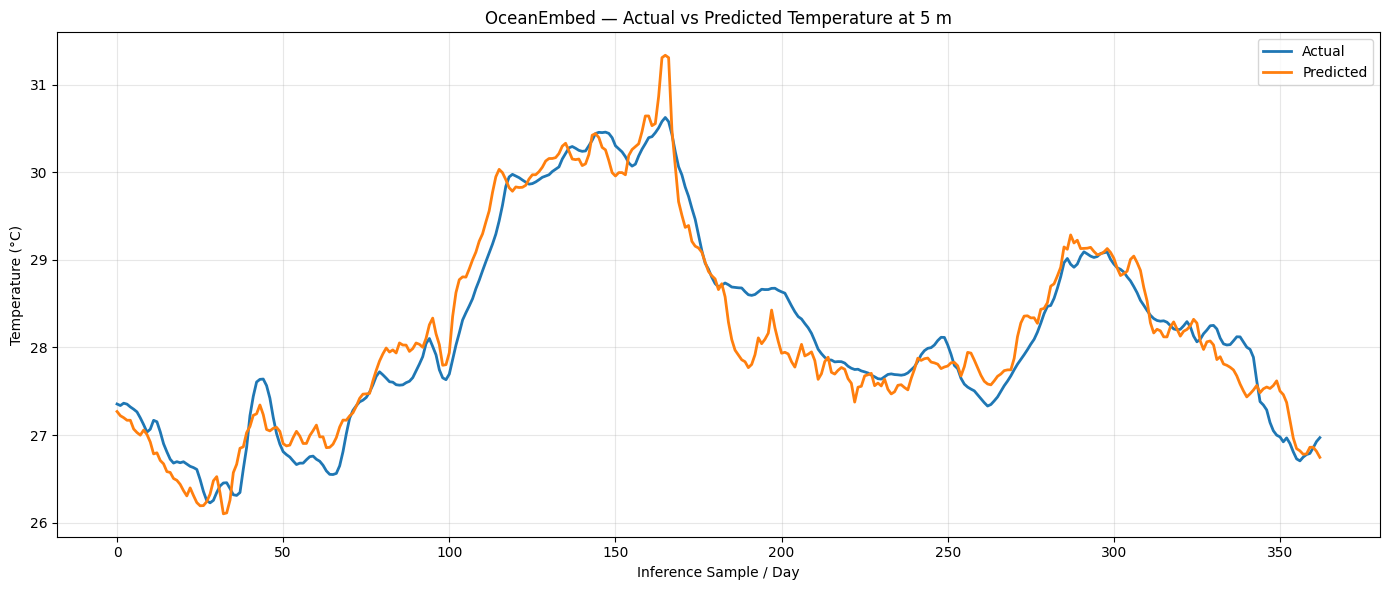

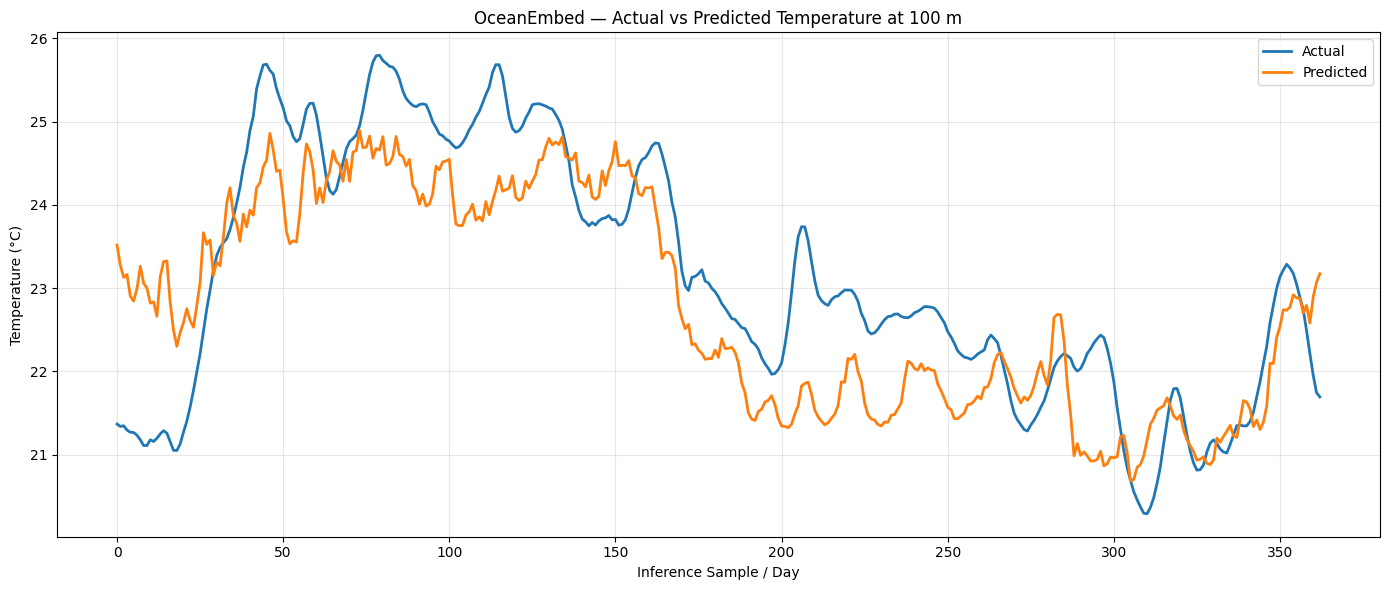

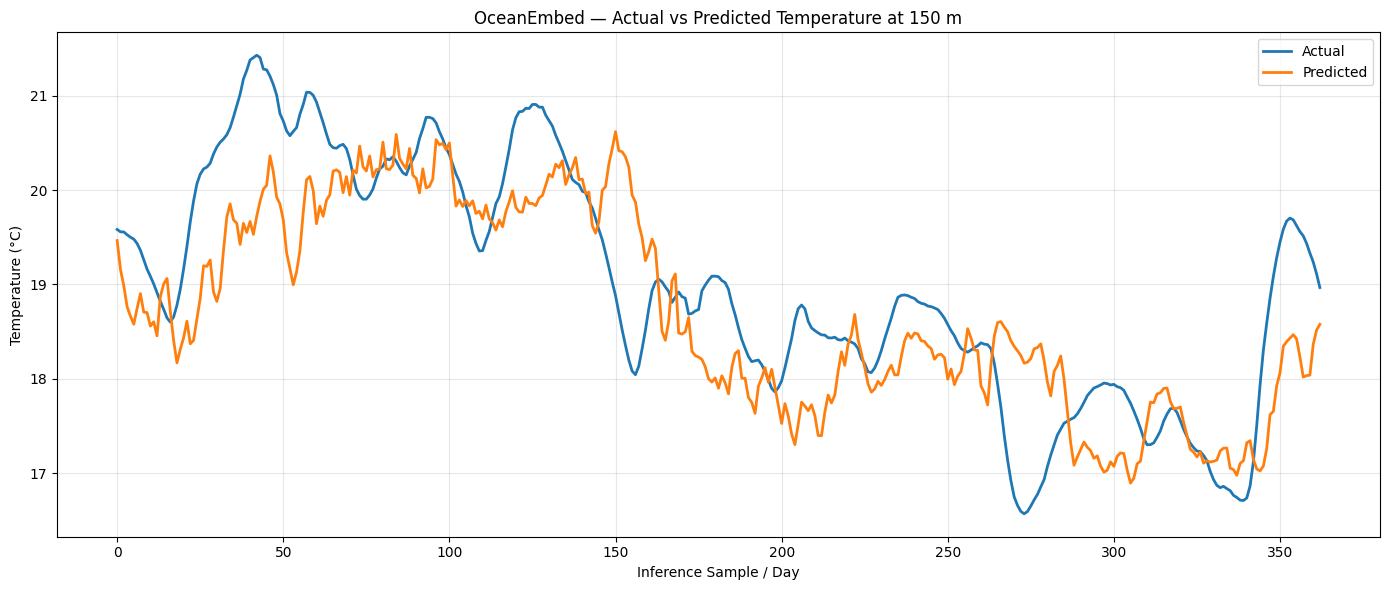

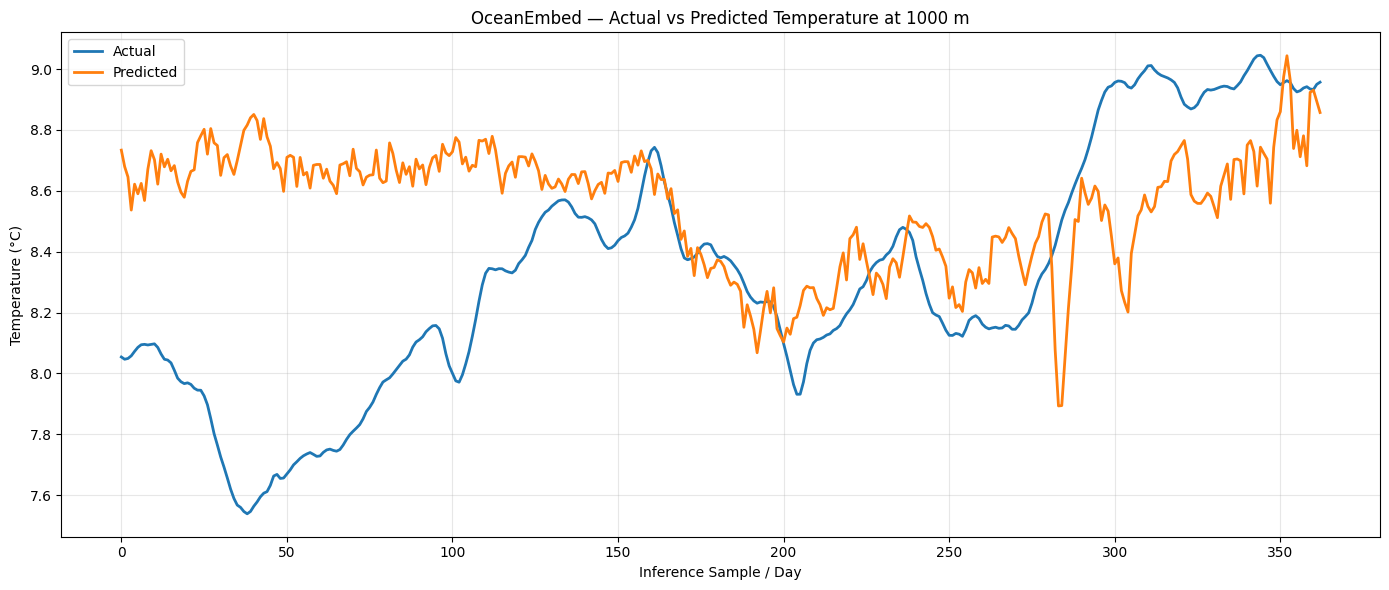

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# LOAD PREDICTIONS
# ============================================================

NPZ_PATH = "/content/drive/MyDrive/OceanEmbeDeTrainingData/predictions_2005_best_model.npz"

data = np.load(NPZ_PATH)

predicted = data["predictions_denorm"]
actual = data["targets_denorm"]
masks = data["masks"]
depths = data["depths"]

print("Actual:", actual.shape)
print("Predicted:", predicted.shape)
print("Depths:", depths)

# ============================================================
# SELECT LOCATION
# ============================================================

lat_index = 50
lon_index = 100

# ============================================================
# SELECT DEPTHS TO VISUALIZE
# ============================================================

depths_to_plot = [5, 100, 150, 1000]

# ============================================================
# CREATE ONE GRAPH PER DEPTH
# ============================================================

for depth in depths_to_plot:

    depth_index = np.argmin(np.abs(depths - depth))

    actual_series = actual[:, depth_index, lat_index, lon_index]
    predicted_series = predicted[:, depth_index, lat_index, lon_index]

    # Mask invalid values
    valid = np.isfinite(actual_series) & np.isfinite(predicted_series)

    actual_series = actual_series[valid]
    predicted_series = predicted_series[valid]

    plt.figure(figsize=(14, 6))

    plt.plot(
        actual_series,
        label="Actual",
        linewidth=2
    )

    plt.plot(
        predicted_series,
        label="Predicted",
        linewidth=2
    )

    plt.xlabel("Inference Sample / Day")
    plt.ylabel("Temperature (°C)")
    plt.title(
        f"OceanEmbed — Actual vs Predicted Temperature at {depths[depth_index]:.0f} m"
    )

    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_1421/4043997494.py:43: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


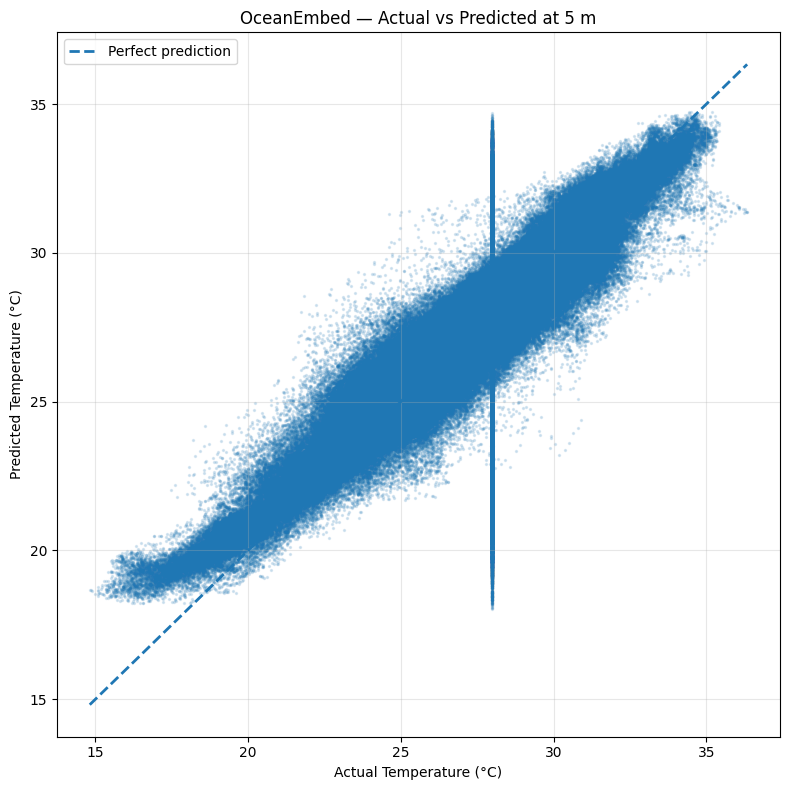

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Pick one depth
depth = 5
depth_index = np.argmin(np.abs(depths - depth))

actual_values = actual[:, depth_index, :, :].flatten()
predicted_values = predicted[:, depth_index, :, :].flatten()

valid = np.isfinite(actual_values) & np.isfinite(predicted_values)

actual_values = actual_values[valid]
predicted_values = predicted_values[valid]

plt.figure(figsize=(8, 8))

plt.scatter(
    actual_values,
    predicted_values,
    s=2,
    alpha=0.15
)

# Perfect prediction line
minimum = min(actual_values.min(), predicted_values.min())
maximum = max(actual_values.max(), predicted_values.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--",
    linewidth=2,
    label="Perfect prediction"
)

plt.xlabel("Actual Temperature (°C)")
plt.ylabel("Predicted Temperature (°C)")
plt.title("OceanEmbed — Actual vs Predicted at 5 m")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Experimentation to get the best model


In [ ]:
# ============================================================
# OCEANEMBED EXPERIMENTATION
# Adapted to the actual training pipeline
# ============================================================

import os
import gc
import json
import copy
import time
import shutil

import numpy as np
import torch
import torch.nn as nn

from pathlib import Path
from torch.utils.data import DataLoader


# ============================================================
# DEVICE
# ============================================================

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )


# ============================================================
# PATHS
# ============================================================

EXPERIMENT_ROOT = (
    DRIVE_ROOT /
    "experiments"
)

EXPERIMENT_ROOT.mkdir(
    parents=True,
    exist_ok=True
)

BEST_DIR = (
    EXPERIMENT_ROOT /
    "best_model"
)

BEST_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# DATA CONFIG
# ============================================================

TRAIN_YEARS = [
    2000,
    2001,
    2002,
    2003,
    2004
]

EVAL_YEAR = 2005

BATCH_SIZE = 64

PATCH_SIZE = 32

PATCH_STRIDE = 32

EPOCHS = 10

LR = 3e-4

WEIGHT_DECAY = 1e-4


# ============================================================
# EXPERIMENTS
# ============================================================

EXPERIMENTS = {

    # -----------------------------------------
    # CURRENT APPROACH
    # -----------------------------------------

    "baseline_huber_seq3": {
        "sequence_length": 3,
        "loss": "huber",
        "depth_weighted": False
    },


    # -----------------------------------------
    # LONGER TEMPORAL CONTEXT
    # -----------------------------------------

    "huber_seq7": {
        "sequence_length": 7,
        "loss": "huber",
        "depth_weighted": False
    },


    # -----------------------------------------
    # DEPTH-WEIGHTED LOSS
    # -----------------------------------------

    "depth_weighted_huber": {
        "sequence_length": 3,
        "loss": "huber",
        "depth_weighted": True
    },


    # -----------------------------------------
    # SEQ7 + DEPTH WEIGHTING
    # -----------------------------------------

    "seq7_depth_weighted": {
        "sequence_length": 7,
        "loss": "huber",
        "depth_weighted": True
    }
}


print()
print("=" * 70)
print("EXPERIMENTS")
print("=" * 70)

for name, config in EXPERIMENTS.items():

    print(
        f"{name:30s}",
        config
    )

Device: cuda
GPU: Tesla T4

EXPERIMENTS
baseline_huber_seq3            {'sequence_length': 3, 'loss': 'huber', 'depth_weighted': False}
huber_seq7                     {'sequence_length': 7, 'loss': 'huber', 'depth_weighted': False}
depth_weighted_huber           {'sequence_length': 3, 'loss': 'huber', 'depth_weighted': True}
seq7_depth_weighted            {'sequence_length': 7, 'loss': 'huber', 'depth_weighted': True}


In [ ]:
# ============================================================
# DEPTH WEIGHTS
# ============================================================

DEPTH_WEIGHTS = torch.tensor(
    [
        1.00,   # 5 m
        1.00,   # 10 m
        1.00,   # 20 m
        1.05,   # 30 m
        1.15,   # 50 m
        1.30,   # 75 m
        1.40,   # 100 m
        1.40,   # 125 m
        1.40,   # 150 m
        1.25,   # 200 m
        1.10,   # 300 m
        1.00,   # 500 m
        1.00,   # 700 m
        1.00    # 1000 m
    ],
    dtype=torch.float32
)


# ============================================================
# EXPERIMENT LOSS
# ============================================================

def experiment_loss(
    prediction,
    target,
    mask,
    loss_type="huber",
    depth_weighted=False,
    delta=1.0
):

    valid = mask > 0

    if valid.sum() == 0:

        return prediction.sum() * 0.0


    # --------------------------------------------------------
    # ELEMENT-WISE LOSS
    # --------------------------------------------------------

    if loss_type == "huber":

        element_loss = torch.nn.functional.huber_loss(
            prediction,
            target,
            reduction="none",
            delta=delta
        )

    elif loss_type == "mse":

        element_loss = (
            prediction - target
        ) ** 2

    else:

        raise ValueError(
            f"Unknown loss: {loss_type}"
        )


    # --------------------------------------------------------
    # DEPTH WEIGHTING
    # --------------------------------------------------------

    if depth_weighted:

        weights = DEPTH_WEIGHTS.to(
            prediction.device,
            dtype=prediction.dtype
        )

        # [14] → [1,14,1,1]

        weights = weights.view(
            1,
            -1,
            1,
            1
        )

        element_loss = (
            element_loss * weights
        )

        weighted_mask = (
            mask * weights
        )

        denominator = (
            weighted_mask.sum()
        )

    else:

        denominator = (
            mask.sum()
        )


    denominator = denominator.clamp_min(
        1.0
    )


    # --------------------------------------------------------
    # MASK
    # --------------------------------------------------------

    element_loss = (
        element_loss * mask
    )


    return (
        element_loss.sum()
        /
        denominator
    )

In [ ]:
# ============================================================
# TRAIN ONE EXPERIMENT
# ============================================================

def train_one_experiment(
    experiment_name,
    config
):

    print("\n")
    print("=" * 70)
    print(
        f"STARTING EXPERIMENT: "
        f"{experiment_name}"
    )
    print("=" * 70)

    print(
        "Configuration:",
        config
    )


    # ========================================================
    # EXPERIMENT DIRECTORY
    # ========================================================

    experiment_dir = (
        EXPERIMENT_ROOT /
        experiment_name
    )

    experiment_dir.mkdir(
        parents=True,
        exist_ok=True
    )


    # ========================================================
    # FRESH MODEL
    # ========================================================

    model = OceanEmbedNet(
        in_channels=14,
        embedding_dim=64,
        out_channels=14
    ).to(DEVICE)


    print(
        "Parameters:",
        sum(
            p.numel()
            for p in model.parameters()
            if p.requires_grad
        )
    )


    # ========================================================
    # FRESH OPTIMIZER
    # ========================================================

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LR,
        weight_decay=WEIGHT_DECAY
    )


    # ========================================================
    # TRACKING
    # ========================================================

    best_eval_loss = float("inf")

    best_epoch = -1

    history = []


    # ========================================================
    # EPOCH LOOP
    # ========================================================

    for epoch in range(
        EPOCHS
    ):

        print("\n")
        print(
            "-" * 70
        )

        print(
            f"{experiment_name} | "
            f"Epoch {epoch + 1}/{EPOCHS}"
        )

        print(
            "-" * 70
        )


        model.train()

        epoch_loss = 0.0

        epoch_batches = 0

        epoch_start = time.time()


        # ====================================================
        # TRAIN YEAR BY YEAR
        # ====================================================

        for year in TRAIN_YEARS:

            print(
                f"\nLoading training year {year}..."
            )


            train_ds = OceanYearDataset(
                year=year,
                data_root=LOCAL_ROOT,
                patch_size=PATCH_SIZE,
                patch_stride=PATCH_STRIDE,
                sequence_length=config[
                    "sequence_length"
                ]
            )


            train_loader = DataLoader(
                train_ds,
                batch_size=BATCH_SIZE,
                shuffle=True,
                num_workers=0,
                pin_memory=True,
                drop_last=True
            )


            print(
                f"Year {year} batches:",
                len(train_loader)
            )


            # =================================================
            # BATCH LOOP
            # =================================================

            for batch_idx, (
                X,
                Y,
                M
            ) in enumerate(
                train_loader
            ):

                X = X.to(
                    DEVICE,
                    non_blocking=True
                )

                Y = Y.to(
                    DEVICE,
                    non_blocking=True
                )

                M = M.to(
                    DEVICE,
                    non_blocking=True
                )


                optimizer.zero_grad(
                    set_to_none=True
                )


                # ---------------------------------------------
                # FORWARD
                # ---------------------------------------------

                prediction = model(X)


                # ---------------------------------------------
                # LOSS
                # ---------------------------------------------

                loss = experiment_loss(
                    prediction,
                    Y,
                    M,
                    loss_type=config[
                        "loss"
                    ],
                    depth_weighted=config[
                        "depth_weighted"
                    ]
                )


                # ---------------------------------------------
                # SAFETY
                # ---------------------------------------------

                if not torch.isfinite(
                    loss
                ):

                    raise RuntimeError(
                        f"NaN/Inf loss in "
                        f"{experiment_name}, "
                        f"year={year}, "
                        f"batch={batch_idx}"
                    )


                # ---------------------------------------------
                # BACKPROP
                # ---------------------------------------------

                loss.backward()


                # ---------------------------------------------
                # GRADIENT CLIPPING
                # ---------------------------------------------

                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=1.0
                )


                # ---------------------------------------------
                # UPDATE
                # ---------------------------------------------

                optimizer.step()


                epoch_loss += loss.item()

                epoch_batches += 1


                # ---------------------------------------------
                # PROGRESS
                # ---------------------------------------------

                if (
                    batch_idx == 0
                    or
                    (batch_idx + 1) % 50 == 0
                    or
                    batch_idx == len(train_loader) - 1
                ):

                    avg_loss = (
                        epoch_loss
                        /
                        max(epoch_batches, 1)
                    )

                    print(
                        f"Epoch {epoch+1:02d} | "
                        f"Year {year} | "
                        f"Batch "
                        f"{batch_idx+1:04d}/"
                        f"{len(train_loader)} | "
                        f"Loss "
                        f"{loss.item():.6f} | "
                        f"Avg "
                        f"{avg_loss:.6f}"
                    )


            # =================================================
            # FREE YEAR
            # =================================================

            del train_loader

            del train_ds

            gc.collect()

            torch.cuda.empty_cache()


        # ====================================================
        # EPOCH TRAIN LOSS
        # ====================================================

        train_loss = (
            epoch_loss
            /
            max(epoch_batches, 1)
        )


        # ====================================================
        # EVALUATION ON 2005
        # ====================================================

        print(
            "\nEvaluating on 2005..."
        )


        eval_ds = OceanYearDataset(
            year=EVAL_YEAR,
            data_root=LOCAL_ROOT,
            patch_size=PATCH_SIZE,
            patch_stride=PATCH_STRIDE,
            sequence_length=config[
                "sequence_length"
            ]
        )


        eval_loader = DataLoader(
            eval_ds,
            batch_size=BATCH_SIZE,
            shuffle=False,
            num_workers=0,
            pin_memory=True
        )


        model.eval()

        eval_loss_total = 0.0

        eval_batches = 0


        with torch.no_grad():

            for X, Y, M in eval_loader:

                X = X.to(
                    DEVICE,
                    non_blocking=True
                )

                Y = Y.to(
                    DEVICE,
                    non_blocking=True
                )

                M = M.to(
                    DEVICE,
                    non_blocking=True
                )


                prediction = model(X)


                loss = experiment_loss(
                    prediction,
                    Y,
                    M,
                    loss_type=config[
                        "loss"
                    ],
                    depth_weighted=config[
                        "depth_weighted"
                    ]
                )


                eval_loss_total += (
                    loss.item()
                )

                eval_batches += 1


        eval_loss = (
            eval_loss_total
            /
            max(eval_batches, 1)
        )


        # ====================================================
        # SAVE HISTORY
        # ====================================================

        history.append(
            {
                "epoch": epoch + 1,
                "train_loss": float(
                    train_loss
                ),
                "eval_loss": float(
                    eval_loss
                )
            }
        )


        # ====================================================
        # SAVE BEST EXPERIMENT CHECKPOINT
        # ====================================================

        if eval_loss < best_eval_loss:

            best_eval_loss = eval_loss

            best_epoch = epoch + 1


            checkpoint = {

                "epoch":
                    epoch + 1,

                "model_state_dict":
                    copy.deepcopy(
                        model.state_dict()
                    ),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "train_loss":
                    float(train_loss),

                "test_loss":
                    float(eval_loss),

                "eval_loss":
                    float(eval_loss),

                "experiment":
                    experiment_name,

                "config":
                    config
            }


            torch.save(
                checkpoint,
                experiment_dir /
                "best.pth"
            )


            print(
                "\n>>> NEW BEST FOR "
                f"{experiment_name}"
            )

            print(
                f"Eval loss: "
                f"{eval_loss:.6f}"
            )

            print(
                f"Epoch: "
                f"{best_epoch}"
            )


        # ====================================================
        # SAVE LATEST
        # ====================================================

        torch.save(
            {
                "epoch":
                    epoch + 1,

                "model_state_dict":
                    model.state_dict(),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "train_loss":
                    float(train_loss),

                "test_loss":
                    float(eval_loss),

                "eval_loss":
                    float(eval_loss),

                "experiment":
                    experiment_name,

                "config":
                    config

            },

            experiment_dir /
            "latest.pth"
        )


        # ====================================================
        # CLEAN EVAL
        # ====================================================

        del eval_loader

        del eval_ds

        gc.collect()

        torch.cuda.empty_cache()


        # ====================================================
        # SUMMARY
        # ====================================================

        elapsed = (
            time.time()
            -
            epoch_start
        ) / 60


        print("\n")
        print(
            "=" * 70
        )

        print(
            f"Epoch {epoch+1} complete"
        )

        print(
            f"Train loss : "
            f"{train_loss:.6f}"
        )

        print(
            f"Eval loss  : "
            f"{eval_loss:.6f}"
        )

        print(
            f"Best eval  : "
            f"{best_eval_loss:.6f}"
        )

        print(
            f"Best epoch : "
            f"{best_epoch}"
        )

        print(
            f"Time       : "
            f"{elapsed:.2f} min"
        )

        print(
            "=" * 70
        )


    # ========================================================
    # SAVE HISTORY
    # ========================================================

    history_path = (
        experiment_dir /
        "history.json"
    )

    with open(
        history_path,
        "w"
    ) as f:

        json.dump(
            history,
            f,
            indent=4
        )


    return {
        "experiment":
            experiment_name,

        "best_eval_loss":
            best_eval_loss,

        "best_epoch":
            best_epoch,

        "config":
            config,

        "checkpoint":
            str(
                experiment_dir /
                "best.pth"
            )
    }

In [ ]:
# ============================================================
# RUN ALL EXPERIMENTS
# ============================================================

all_results = []

global_best_loss = float("inf")

global_best_experiment = None

global_best_checkpoint = None


for experiment_name, config in EXPERIMENTS.items():

    result = train_one_experiment(
        experiment_name,
        config
    )

    all_results.append(
        result
    )


    # ========================================================
    # GLOBAL BEST
    # ========================================================

    if (
        result["best_eval_loss"]
        <
        global_best_loss
    ):

        global_best_loss = (
            result["best_eval_loss"]
        )

        global_best_experiment = (
            experiment_name
        )

        source = Path(
            result["checkpoint"]
        )

        destination = (
            BEST_DIR /
            "OceanEmbed_GLOBAL_BEST.pth"
        )


        # Copy exact checkpoint

        shutil.copy2(
            source,
            destination
        )


        global_best_checkpoint = (
            destination
        )


        print("\n")
        print(
            "!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!"
        )

        print(
            "GLOBAL BEST MODEL UPDATED"
        )

        print(
            f"Experiment: "
            f"{experiment_name}"
        )

        print(
            f"Eval loss: "
            f"{global_best_loss:.6f}"
        )

        print(
            f"Saved to:"
        )

        print(
            destination
        )

        print(
            "!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!"
        )


# ============================================================
# SAVE EXPERIMENT SUMMARY
# ============================================================

summary_path = (
    EXPERIMENT_ROOT /
    "experiment_results.json"
)


with open(
    summary_path,
    "w"
) as f:

    json.dump(
        all_results,
        f,
        indent=4
    )


# ============================================================
# PRINT FINAL RESULTS
# ============================================================

print("\n")
print("=" * 80)
print("ALL EXPERIMENTS COMPLETE")
print("=" * 80)


for result in sorted(
    all_results,
    key=lambda x: x["best_eval_loss"]
):

    print(
        f"{result['experiment']:30s} "
        f"loss = "
        f"{result['best_eval_loss']:.6f} "
        f"epoch = "
        f"{result['best_epoch']}"
    )


print("\n")
print("=" * 80)
print("GLOBAL BEST")
print("=" * 80)

print(
    "Experiment:",
    global_best_experiment
)

print(
    "Loss:",
    f"{global_best_loss:.6f}"
)

print(
    "Checkpoint:",
    global_best_checkpoint
)

print(
    "Results:",
    summary_path
)



STARTING EXPERIMENT: baseline_huber_seq3
Configuration: {'sequence_length': 3, 'loss': 'huber', 'depth_weighted': False}
Parameters: 142942


----------------------------------------------------------------------
baseline_huber_seq3 | Epoch 1/10
----------------------------------------------------------------------

Loading training year 2000...

Loading 2000: /content/OceanEmbeDeTrainingData/modelready_2000.nc
X: (366, 14, 100, 240)
Y: (366, 14, 100, 240)
M: (366, 14, 100, 240)
RAM: 1.37 GB
Samples: 7644
Year 2000 batches: 119
Epoch 01 | Year 2000 | Batch 0001/119 | Loss 0.483583 | Avg 0.483583
Epoch 01 | Year 2000 | Batch 0050/119 | Loss 0.194036 | Avg 0.264784
Epoch 01 | Year 2000 | Batch 0100/119 | Loss 0.132125 | Avg 0.215822
Epoch 01 | Year 2000 | Batch 0119/119 | Loss 0.110090 | Avg 0.202897

Loading training year 2001...

Loading 2001: /content/OceanEmbeDeTrainingData/modelready_2001.nc
X: (365, 14, 100, 240)
Y: (365, 14, 100, 240)
M: (365, 14, 100, 240)
RAM: 1.37 GB
Samples:

In [ ]:
# ============================================================
# OCEANEMBED — COMPLETE TESTING & VISUALIZATION
# Best model: huber_seq7
# Test year: 2005
# ============================================================

import os
import json
import math
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

TEST_FILE = Path(
    "/content/OceanEmbeDeTrainingData/modelready_2005.nc"
)

CHECKPOINT = Path(
    "/content/drive/MyDrive/OceanEmbeDeTrainingData/"
    "experiments/best_model/OceanEmbed_GLOBAL_BEST.pth"
)

OUTPUT_DIR = Path(
    "/content/OceanEmbed_test_results"
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Model configuration
# ------------------------------------------------------------

SEQUENCE_LENGTH = 7
N_CHANNELS = 14
N_OUTPUTS = 14

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)
print("Test file:", TEST_FILE)
print("Checkpoint:", CHECKPOINT)
print("Output directory:", OUTPUT_DIR)

Device: cuda
Test file: /content/OceanEmbeDeTrainingData/modelready_2005.nc
Checkpoint: /content/drive/MyDrive/OceanEmbeDeTrainingData/experiments/best_model/OceanEmbed_GLOBAL_BEST.pth
Output directory: /content/OceanEmbed_test_results


In [ ]:
# ============================================================
# LOAD BEST MODEL CHECKPOINT
# ============================================================

checkpoint = torch.load(
    CHECKPOINT,
    map_location=DEVICE
)

print("Checkpoint type:", type(checkpoint))

if isinstance(checkpoint, dict):
    print("\nCheckpoint keys:")
    print(checkpoint.keys())

Checkpoint type: <class 'dict'>

Checkpoint keys:
dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'train_loss', 'test_loss', 'eval_loss', 'experiment', 'config'])


In [ ]:
# ============================================================
# EXTRACT STATE DICT SAFELY
# ============================================================

if isinstance(checkpoint, dict):

    if "model_state_dict" in checkpoint:
        state_dict = checkpoint["model_state_dict"]

    elif "state_dict" in checkpoint:
        state_dict = checkpoint["state_dict"]

    else:
        # Sometimes checkpoint itself is state_dict
        state_dict = checkpoint

else:
    raise ValueError(
        "Unexpected checkpoint format."
    )

# Remove possible DataParallel prefix
clean_state_dict = {}

for k, v in state_dict.items():

    if k.startswith("module."):
        k = k.replace("module.", "", 1)

    clean_state_dict[k] = v

print(
    "Number of checkpoint tensors:",
    len(clean_state_dict)
)

Number of checkpoint tensors: 45


In [ ]:
# ============================================================
# LOAD WEIGHTS
# ============================================================

missing, unexpected = model.load_state_dict(
    clean_state_dict,
    strict=False
)

print("\nMissing keys:")
print(missing)

print("\nUnexpected keys:")
print(unexpected)

model = model.to(DEVICE)
model.eval()

print("\nModel loaded successfully.")


Missing keys:
[]

Unexpected keys:
[]

Model loaded successfully.


In [ ]:
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", DEVICE)

Using device: cuda


OCEANEMBED — FINAL 2005 EVALUATION
Device          : cuda
Test year       : 2005
Sequence length : 7
Patch size      : 32
Patch stride    : 32
Batch size      : 2
GPU             : Tesla T4

Local dataset directory exists.

2005 dataset: /content/OceanEmbeDeTrainingData/modelready_2005.nc
Checkpoint   : /content/drive/MyDrive/OceanEmbeDeTrainingData/experiments/best_model/OceanEmbed_GLOBAL_BEST.pth

Model parameters: 142,942

LOADING BEST CHECKPOINT
Checkpoint loaded.
Checkpoint type: <class 'dict'>

Missing keys: []
Unexpected keys: []

BEST MODEL LOADED SUCCESSFULLY.

CREATING 2005 TEST DATASET

Loading 2005: /content/OceanEmbeDeTrainingData/modelready_2005.nc
X: (365, 14, 100, 240)
Y: (365, 14, 100, 240)
M: (365, 14, 100, 240)
RAM: 1.37 GB
Samples: 7539

TOTAL TEST SAMPLES: 7539
TEST BATCHES: 3770

STARTING 2005 INFERENCE
RAM-safe mode: only current batch is processed.
Processed 1 / 3,770
Processed 50 / 3,770
Processed 100 / 3,770
Processed 150 / 3,770
Processed 200 / 3,770
Processe

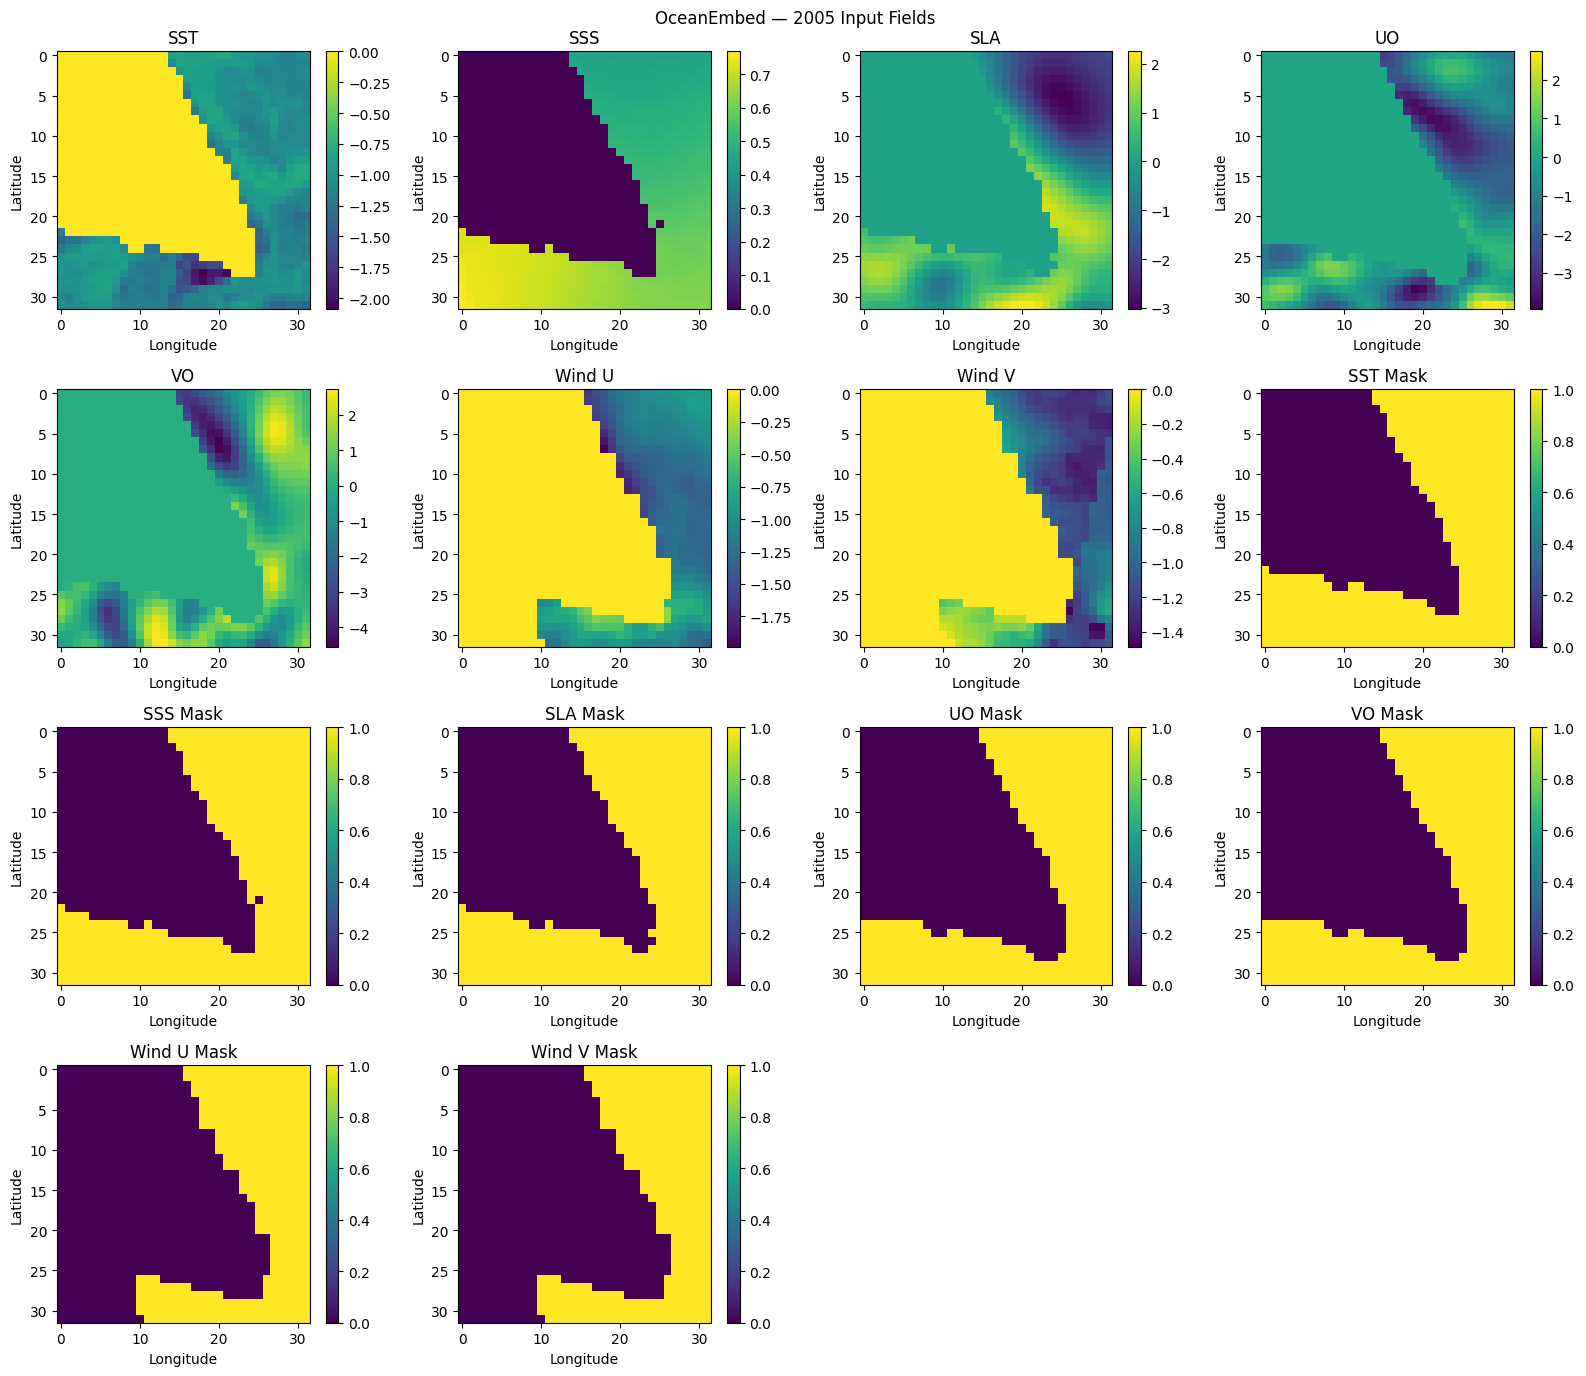

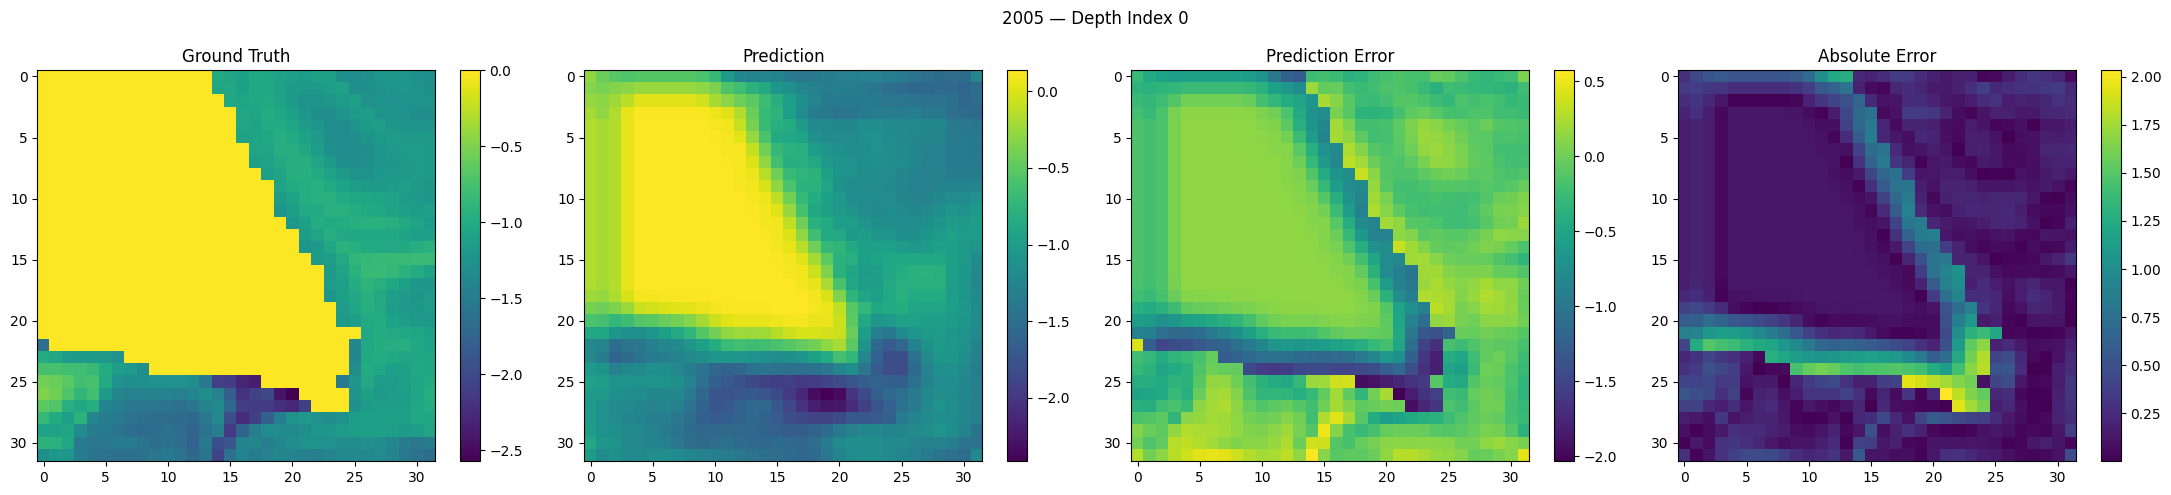

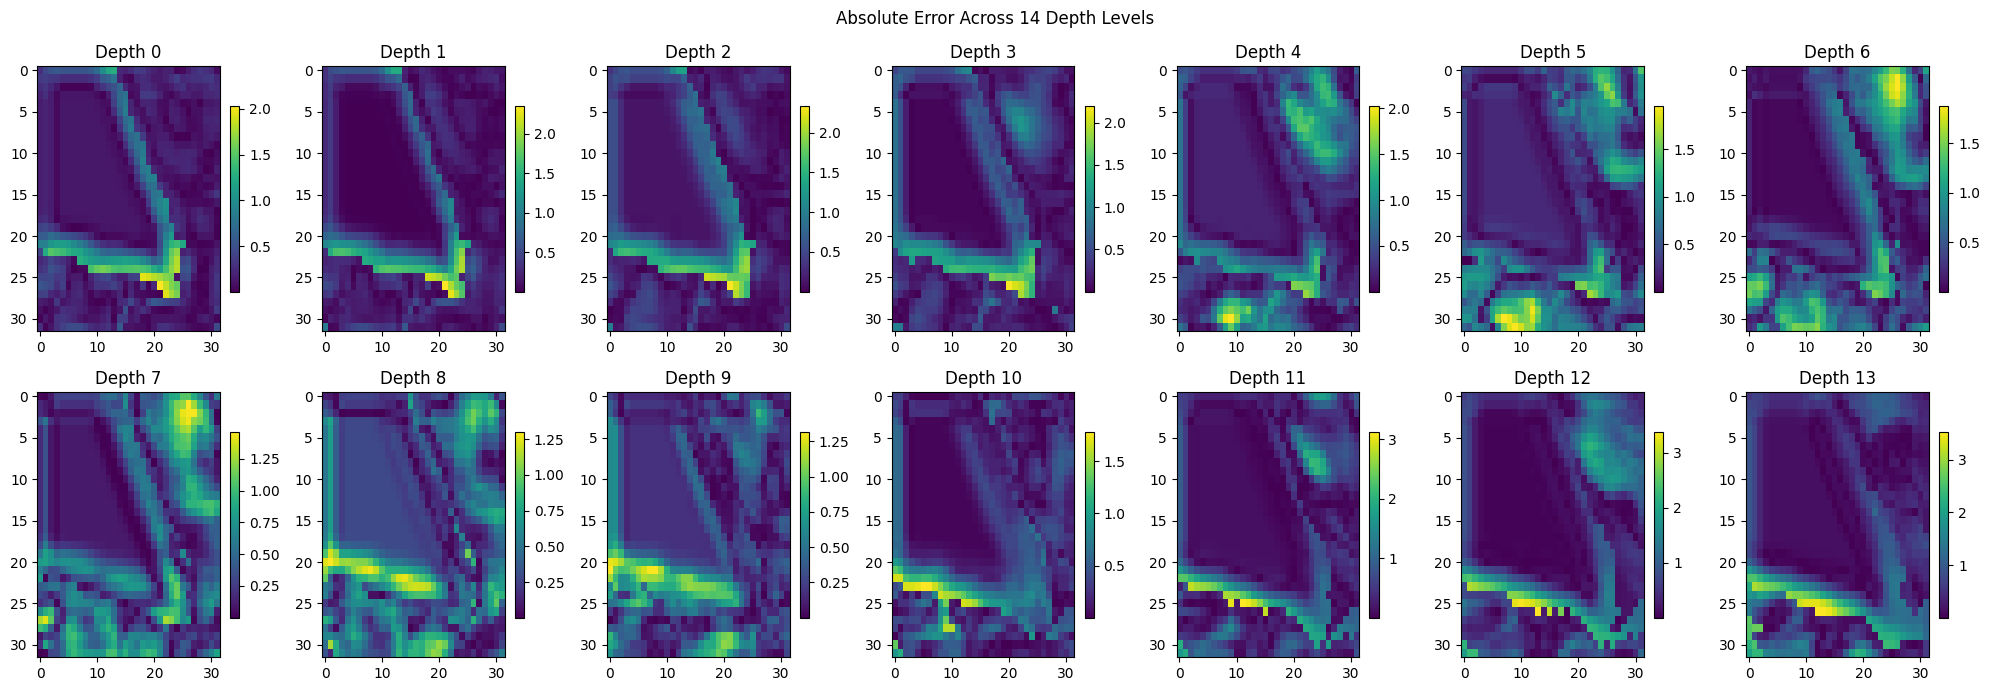

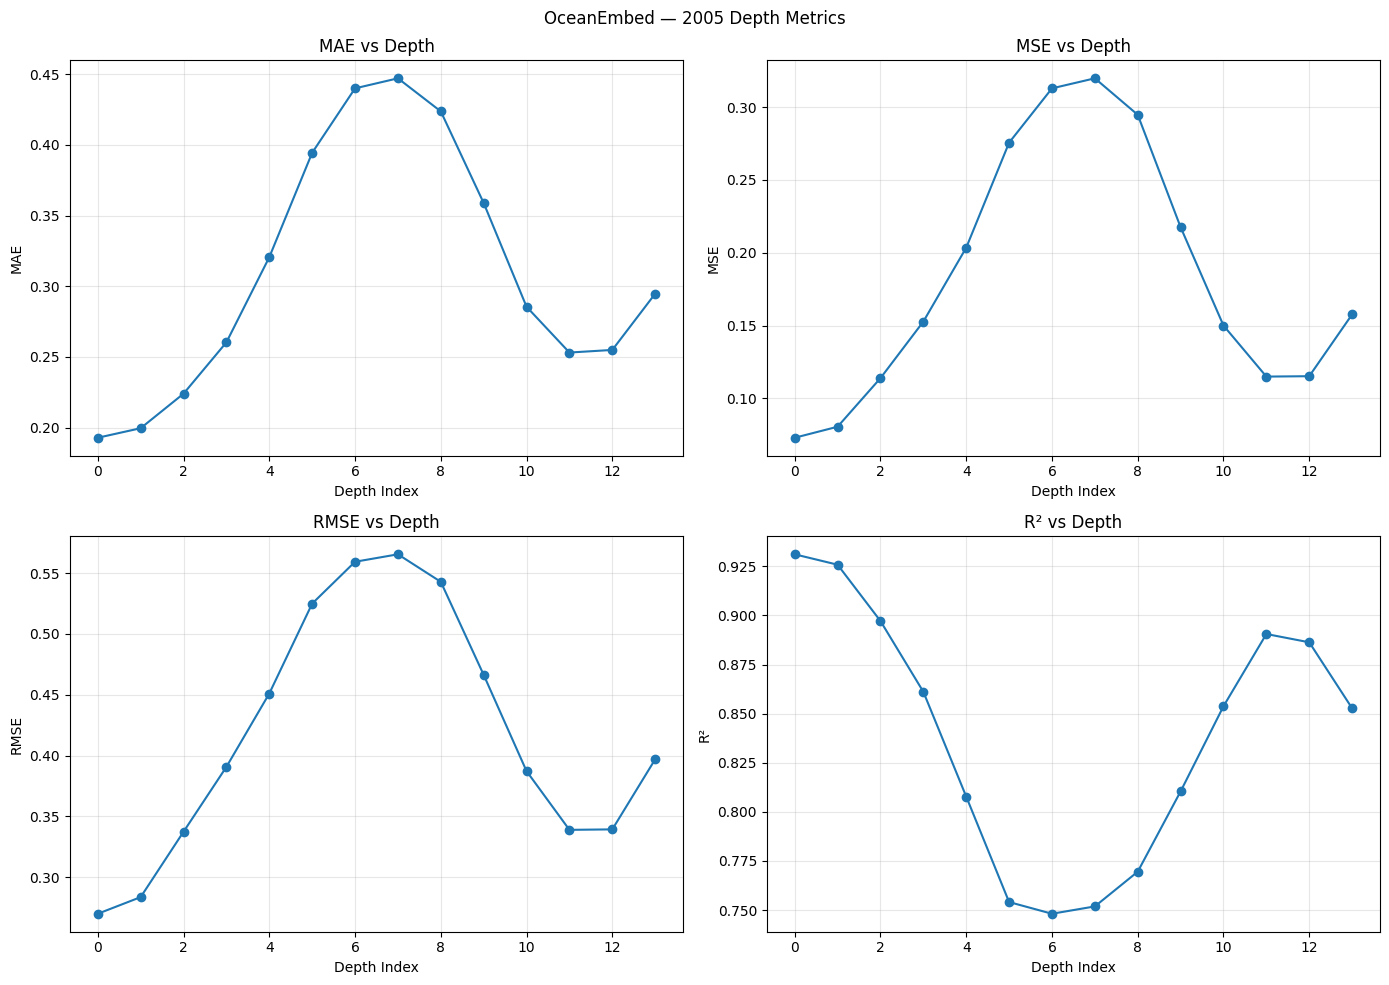

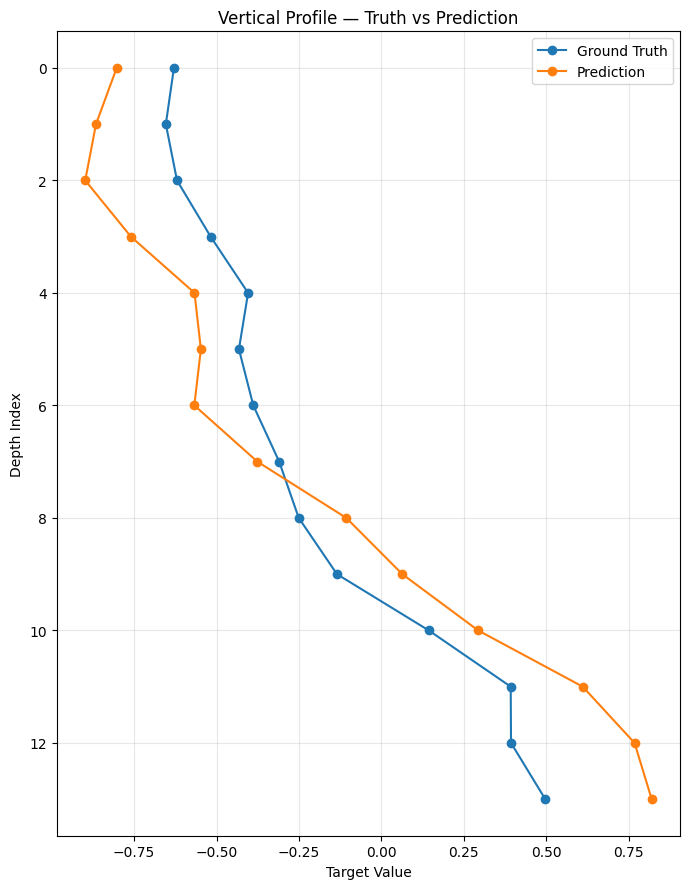



2005 EVALUATION COMPLETE
Model        : huber_seq7
Test year    : 2005
Samples      : 7,539
MAE          : 0.307661
MSE          : 0.181993
RMSE         : 0.426606
R²           : 0.837656
Bias         : 0.026341

Saved results:
  all_depth_errors_2005.png
  depth_metrics_2005.csv
  depth_metrics_2005.png
  input_fields_2005.png
  overall_metrics_2005.csv
  truth_prediction_error_2005.png
  vertical_profile_2005.png

Output directory:
/content/OceanEmbed_test_results

DONE.


In [ ]:
# =====================================================================
# OCEANEMBED — FINAL 2005 EVALUATION
# =====================================================================
#
# THIS IS A SINGLE STANDALONE CELL
#
# Exact notebook configuration:
#   Input channels  = 14
#   Output channels = 14
#   Best experiment = huber_seq7
#   Sequence length = 7
#   Patch size      = 32
#   Patch stride    = 32
#   Test year       = 2005
#
# DOES NOT TRAIN.
#
# IMPORTANT:
# We DO NOT store all predictions in RAM.
# Metrics are accumulated batch-by-batch.
# Only ONE sample is kept for visualization.
# =====================================================================


# =====================================================================
# 1. IMPORTS
# =====================================================================

import os
import gc
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader


# =====================================================================
# 2. GOOGLE DRIVE / PATHS
# =====================================================================

DRIVE_ROOT = Path(
    "/content/drive/MyDrive/OceanEmbeDeTrainingData"
)

LOCAL_ROOT = Path(
    "/content/OceanEmbeDeTrainingData"
)

TEST_YEAR = 2005

PATCH_SIZE = 32

PATCH_STRIDE = 32

SEQUENCE_LENGTH = 7

BATCH_SIZE = 2


CHECKPOINT = (
    DRIVE_ROOT
    / "experiments"
    / "best_model"
    / "OceanEmbed_GLOBAL_BEST.pth"
)


TEST_FILE = (
    LOCAL_ROOT
    / "modelready_2005.nc"
)


OUTPUT_DIR = Path(
    "/content/OceanEmbed_test_results"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# =====================================================================
# 3. DEVICE
# =====================================================================

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


print("=" * 75)
print("OCEANEMBED — FINAL 2005 EVALUATION")
print("=" * 75)

print(
    "Device          :",
    DEVICE
)

print(
    "Test year       :",
    TEST_YEAR
)

print(
    "Sequence length :",
    SEQUENCE_LENGTH
)

print(
    "Patch size      :",
    PATCH_SIZE
)

print(
    "Patch stride    :",
    PATCH_STRIDE
)

print(
    "Batch size      :",
    BATCH_SIZE
)


if torch.cuda.is_available():

    print(
        "GPU             :",
        torch.cuda.get_device_name(0)
    )

    torch.cuda.empty_cache()


gc.collect()


# =====================================================================
# 4. CHECK DRIVE
# =====================================================================

if not DRIVE_ROOT.exists():

    raise FileNotFoundError(
        "\nGoogle Drive path not found:\n"
        f"{DRIVE_ROOT}\n\n"
        "Mount Google Drive first."
    )


# =====================================================================
# 5. CHECK / COPY LOCAL DATA
# =====================================================================

if not LOCAL_ROOT.exists():

    print(
        "\nLocal dataset directory not found."
    )

    print(
        "Copying from Google Drive..."
    )

    shutil.copytree(
        DRIVE_ROOT,
        LOCAL_ROOT
    )

    print(
        "Copy complete."
    )

else:

    print(
        "\nLocal dataset directory exists."
    )


if not TEST_FILE.exists():

    raise FileNotFoundError(
        "\n2005 dataset not found:\n"
        f"{TEST_FILE}"
    )


if not CHECKPOINT.exists():

    raise FileNotFoundError(
        "\nBest checkpoint not found:\n"
        f"{CHECKPOINT}"
    )


print(
    "\n2005 dataset:",
    TEST_FILE
)

print(
    "Checkpoint   :",
    CHECKPOINT
)


# =====================================================================
# 6. EXACT MODEL FROM NOTEBOOK CELL 3
# =====================================================================

class OceanEmbedNet(nn.Module):

    def __init__(
        self,
        in_channels=14,
        embedding_dim=64,
        out_channels=14
    ):

        super().__init__()


        # -------------------------------------------------------------
        # CNN ENCODER
        # -------------------------------------------------------------

        self.encoder = nn.Sequential(

            nn.Conv2d(
                in_channels,
                32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(32),

            nn.ReLU(
                inplace=True
            ),

            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(64),

            nn.ReLU(
                inplace=True
            ),

            nn.Conv2d(
                64,
                64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(64),

            nn.ReLU(
                inplace=True
            )
        )


        # -------------------------------------------------------------
        # TEMPORAL GRU
        # -------------------------------------------------------------

        self.gru = nn.GRU(

            input_size=64,

            hidden_size=64,

            num_layers=1,

            batch_first=True
        )


        # -------------------------------------------------------------
        # CHANNEL ATTENTION
        # -------------------------------------------------------------

        self.attention_pool = (
            nn.AdaptiveAvgPool2d(1)
        )


        self.attention = nn.Sequential(

            nn.Linear(
                64,
                16
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Linear(
                16,
                64
            ),

            nn.Sigmoid()
        )


        # -------------------------------------------------------------
        # DECODER
        # -------------------------------------------------------------

        self.decoder = nn.Sequential(

            nn.Conv2d(
                64,
                64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(64),

            nn.ReLU(
                inplace=True
            ),

            nn.Conv2d(
                64,
                32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(32),

            nn.ReLU(
                inplace=True
            ),

            nn.Conv2d(
                32,
                out_channels,
                kernel_size=1
            )
        )


    def forward(
        self,
        x,
        return_embedding=False
    ):

        # x = [B,T,C,H,W]

        B, T, C, H, W = x.shape


        encoded = []


        # -------------------------------------------------------------
        # SPATIAL ENCODER
        # -------------------------------------------------------------

        for t in range(T):

            z = self.encoder(
                x[:, t]
            )

            encoded.append(z)


        encoded = torch.stack(
            encoded,
            dim=1
        )


        # -------------------------------------------------------------
        # TEMPORAL GRU
        # -------------------------------------------------------------

        gru_input = encoded.permute(
            0,
            3,
            4,
            1,
            2
        )


        gru_input = gru_input.reshape(
            B * H * W,
            T,
            64
        )


        gru_output, _ = self.gru(
            gru_input
        )


        z = gru_output[:, -1]


        z = z.reshape(
            B,
            H,
            W,
            64
        )


        z = z.permute(
            0,
            3,
            1,
            2
        )


        # -------------------------------------------------------------
        # CHANNEL ATTENTION
        # -------------------------------------------------------------

        pooled = self.attention_pool(
            z
        )


        pooled = pooled.reshape(
            B,
            64
        )


        weights = self.attention(
            pooled
        )


        weights = weights.reshape(
            B,
            64,
            1,
            1
        )


        z = z * weights


        embedding = z


        # -------------------------------------------------------------
        # DECODER
        # -------------------------------------------------------------

        output = self.decoder(
            z
        )


        if return_embedding:

            return output, embedding


        return output


# =====================================================================
# 7. CREATE EXACT MODEL
# =====================================================================

model = OceanEmbedNet(
    in_channels=14,
    embedding_dim=64,
    out_channels=14
).to(DEVICE)


parameter_count = sum(
    p.numel()
    for p in model.parameters()
)


print(
    "\nModel parameters:",
    f"{parameter_count:,}"
)


# Expected from your notebook:
# 142,942


# =====================================================================
# 8. LOAD BEST CHECKPOINT
# =====================================================================

print("\n" + "=" * 75)
print("LOADING BEST CHECKPOINT")
print("=" * 75)


checkpoint = torch.load(
    CHECKPOINT,
    map_location=DEVICE
)


print(
    "Checkpoint loaded."
)


print(
    "Checkpoint type:",
    type(checkpoint)
)


# =====================================================================
# 9. EXTRACT STATE DICT
# =====================================================================

if isinstance(
    checkpoint,
    dict
):

    if "model_state_dict" in checkpoint:

        state_dict = (
            checkpoint["model_state_dict"]
        )

    elif "state_dict" in checkpoint:

        state_dict = (
            checkpoint["state_dict"]
        )

    else:

        state_dict = checkpoint

else:

    raise ValueError(
        "Unexpected checkpoint format."
    )


# Remove DataParallel prefix if present

clean_state_dict = {}

for key, value in state_dict.items():

    if key.startswith(
        "module."
    ):

        key = key.replace(
            "module.",
            "",
            1
        )

    clean_state_dict[
        key
    ] = value


# =====================================================================
# 10. LOAD WEIGHTS
# =====================================================================

missing_keys, unexpected_keys = (
    model.load_state_dict(
        clean_state_dict,
        strict=False
    )
)


print(
    "\nMissing keys:",
    missing_keys
)

print(
    "Unexpected keys:",
    unexpected_keys
)


if len(missing_keys) > 0:

    raise RuntimeError(
        "Checkpoint has missing model weights. "
        "STOP — do not continue."
    )


model.eval()


print(
    "\nBEST MODEL LOADED SUCCESSFULLY."
)


# =====================================================================
# 11. EXACT DATASET FROM NOTEBOOK CELL 5
# =====================================================================

class OceanYearDataset(Dataset):

    def __init__(
        self,
        year,
        data_root,
        patch_size=32,
        patch_stride=32,
        sequence_length=3
    ):

        self.year = year

        self.patch_size = patch_size

        self.patch_stride = patch_stride

        self.sequence_length = sequence_length


        path = (
            data_root
            /
            f"modelready_{year}.nc"
        )


        print(
            f"\nLoading {year}: {path}"
        )


        ds = xr.open_dataset(
            path,
            engine="h5netcdf"
        )


        # -------------------------------------------------------------
        # SURFACE VARIABLES
        # -------------------------------------------------------------

        surface_vars = [

            "sst",

            "sss",

            "sla",

            "uo",

            "vo",

            "wind_u",

            "wind_v"

        ]


        # -------------------------------------------------------------
        # MASK VARIABLES
        # -------------------------------------------------------------

        mask_vars = [

            "sst_mask",

            "sss_mask",

            "sla_mask",

            "uo_mask",

            "vo_mask",

            "wind_u_mask",

            "wind_v_mask"

        ]


        # -------------------------------------------------------------
        # INPUT
        # -------------------------------------------------------------

        surface = np.stack(

            [

                ds[v].values.astype(
                    np.float32
                )

                for v in surface_vars

            ],

            axis=1

        )


        masks = np.stack(

            [

                ds[v].values.astype(
                    np.float32
                )

                for v in mask_vars

            ],

            axis=1

        )


        self.X = np.concatenate(

            [

                surface,

                masks

            ],

            axis=1

        )


        # -------------------------------------------------------------
        # TARGET
        # -------------------------------------------------------------

        self.Y = ds[
            "thetao"
        ].values.astype(
            np.float32
        )


        # -------------------------------------------------------------
        # TARGET MASK
        # -------------------------------------------------------------

        self.M = ds[
            "thetao_mask"
        ].values.astype(
            np.float32
        )


        ds.close()


        # -------------------------------------------------------------
        # EXACT NOTEBOOK NaN HANDLING
        # -------------------------------------------------------------

        self.Y = np.nan_to_num(

            self.Y,

            nan=0.0,

            posinf=0.0,

            neginf=0.0

        )


        print(
            "X:",
            self.X.shape
        )

        print(
            "Y:",
            self.Y.shape
        )

        print(
            "M:",
            self.M.shape
        )


        total_ram = (

            self.X.nbytes

            +

            self.Y.nbytes

            +

            self.M.nbytes

        )


        print(

            "RAM:",

            round(
                total_ram / 1024**3,
                2
            ),

            "GB"

        )


        # -------------------------------------------------------------
        # SAMPLE INDEX
        # -------------------------------------------------------------

        ntime = self.X.shape[0]

        nlat = self.X.shape[2]

        nlon = self.X.shape[3]


        self.samples = []


        for t in range(

            sequence_length - 1,

            ntime

        ):

            for lat in range(

                0,

                nlat - patch_size + 1,

                patch_stride

            ):

                for lon in range(

                    0,

                    nlon - patch_size + 1,

                    patch_stride

                ):

                    self.samples.append(

                        (

                            t,

                            lat,

                            lon

                        )

                    )


        print(
            "Samples:",
            len(self.samples)
        )


    def __len__(self):

        return len(
            self.samples
        )


    def __getitem__(
        self,
        idx
    ):

        t, lat, lon = (
            self.samples[idx]
        )


        ps = self.patch_size

        sl = self.sequence_length


        X = self.X[

            t-sl+1:t+1,

            :,

            lat:lat+ps,

            lon:lon+ps

        ]


        Y = self.Y[

            t,

            :,

            lat:lat+ps,

            lon:lon+ps

        ]


        M = self.M[

            t,

            :,

            lat:lat+ps,

            lon:lon+ps

        ]


        return (

            torch.from_numpy(
                X.copy()
            ),

            torch.from_numpy(
                Y.copy()
            ),

            torch.from_numpy(
                M.copy()
            )

        )


# =====================================================================
# 12. CREATE 2005 DATASET
# =====================================================================

print("\n" + "=" * 75)
print("CREATING 2005 TEST DATASET")
print("=" * 75)


test_dataset = OceanYearDataset(

    year=2005,

    data_root=LOCAL_ROOT,

    patch_size=32,

    patch_stride=32,

    sequence_length=7

)


print(
    "\nTOTAL TEST SAMPLES:",
    len(test_dataset)
)


# =====================================================================
# 13. TEST LOADER
# =====================================================================

test_loader = DataLoader(

    test_dataset,

    batch_size=2,

    shuffle=False,

    num_workers=0,

    pin_memory=False,

    drop_last=False

)


print(
    "TEST BATCHES:",
    len(test_loader)
)


# =====================================================================
# 14. LOW-RAM METRIC ACCUMULATORS
# =====================================================================

N_DEPTHS = 14


# Number of valid pixels

count = np.zeros(
    N_DEPTHS,
    dtype=np.int64
)


# Sum |prediction - truth|

sum_abs_error = np.zeros(
    N_DEPTHS,
    dtype=np.float64
)


# Sum (prediction - truth)^2

sum_squared_error = np.zeros(
    N_DEPTHS,
    dtype=np.float64
)


# Sum prediction - truth

sum_error = np.zeros(
    N_DEPTHS,
    dtype=np.float64
)


# Sum truth

sum_truth = np.zeros(
    N_DEPTHS,
    dtype=np.float64
)


# Sum truth^2

sum_truth_squared = np.zeros(
    N_DEPTHS,
    dtype=np.float64
)


# =====================================================================
# 15. ONE SAMPLE ONLY FOR VISUALIZATION
# =====================================================================

visual_X = None

visual_Y = None

visual_P = None

visual_M = None


# =====================================================================
# 16. RUN INFERENCE
# =====================================================================

print("\n" + "=" * 75)
print("STARTING 2005 INFERENCE")
print("=" * 75)

print(
    "RAM-safe mode: only current batch is processed."
)


with torch.inference_mode():

    for batch_idx, (
        X,
        Y,
        M
    ) in enumerate(
        test_loader
    ):


        # -------------------------------------------------------------
        # Keep FIRST sample only
        # -------------------------------------------------------------

        if batch_idx == 0:

            visual_X = (
                X[0]
                .numpy()
                .copy()
            )

            visual_Y = (
                Y[0]
                .numpy()
                .copy()
            )

            visual_M = (
                M[0]
                .numpy()
                .copy()
            )


        # -------------------------------------------------------------
        # GPU
        # -------------------------------------------------------------

        X = X.to(
            DEVICE
        )

        Y = Y.to(
            DEVICE
        )


        # -------------------------------------------------------------
        # MODEL
        # -------------------------------------------------------------

        P = model(
            X
        )


        # -------------------------------------------------------------
        # Save first prediction only
        # -------------------------------------------------------------

        if batch_idx == 0:

            visual_P = (
                P[0]
                .detach()
                .cpu()
                .numpy()
                .copy()
            )


        # -------------------------------------------------------------
        # Move batch to CPU
        # -------------------------------------------------------------

        P_np = (
            P.detach()
            .cpu()
            .numpy()
        )

        Y_np = (
            Y.detach()
            .cpu()
            .numpy()
        )

        M_np = (
            M.numpy()
        )


        # -------------------------------------------------------------
        # DEPTH-WISE ACCUMULATION
        # -------------------------------------------------------------

        for d in range(
            N_DEPTHS
        ):

            truth = Y_np[:, d]

            pred = P_np[:, d]

            mask = M_np[:, d]


            valid = (

                np.isfinite(
                    truth
                )

                &

                np.isfinite(
                    pred
                )

                &

                (mask > 0)

            )


            if not np.any(valid):

                continue


            truth = truth[
                valid
            ]

            pred = pred[
                valid
            ]


            error = (
                pred - truth
            )


            count[d] += (
                truth.size
            )


            sum_abs_error[d] += np.sum(

                np.abs(error),

                dtype=np.float64

            )


            sum_squared_error[d] += np.sum(

                error ** 2,

                dtype=np.float64

            )


            sum_error[d] += np.sum(

                error,

                dtype=np.float64

            )


            sum_truth[d] += np.sum(

                truth,

                dtype=np.float64

            )


            sum_truth_squared[d] += np.sum(

                truth ** 2,

                dtype=np.float64

            )


        # -------------------------------------------------------------
        # DELETE BATCH
        # -------------------------------------------------------------

        del X

        del Y

        del M

        del P

        del P_np

        del Y_np

        del M_np

        gc.collect()


        # -------------------------------------------------------------
        # PROGRESS
        # -------------------------------------------------------------

        if (

            batch_idx == 0

            or

            (batch_idx + 1) % 50 == 0

            or

            batch_idx + 1 == len(
                test_loader
            )

        ):

            print(

                f"Processed "
                f"{batch_idx + 1:,} / "
                f"{len(test_loader):,}"

            )


# =====================================================================
# 17. CALCULATE DEPTH METRICS
# =====================================================================

depth_rows = []


for d in range(
    N_DEPTHS
):

    n = count[d]


    if n == 0:

        depth_rows.append({

            "Depth_Index": d,

            "MAE": np.nan,

            "MSE": np.nan,

            "RMSE": np.nan,

            "R2": np.nan,

            "Bias": np.nan,

            "Valid_N": 0

        })

        continue


    mae = (

        sum_abs_error[d]
        /
        n

    )


    mse = (

        sum_squared_error[d]
        /
        n

    )


    rmse = np.sqrt(
        mse
    )


    bias = (

        sum_error[d]
        /
        n

    )


    # -------------------------------------------------------------
    # R2
    # -------------------------------------------------------------

    ss_res = (
        sum_squared_error[d]
    )


    ss_tot = (

        sum_truth_squared[d]

        -

        (
            sum_truth[d] ** 2
            /
            n
        )

    )


    if ss_tot > 0:

        r2 = (

            1.0
            -
            ss_res / ss_tot

        )

    else:

        r2 = np.nan


    depth_rows.append({

        "Depth_Index": d,

        "MAE": mae,

        "MSE": mse,

        "RMSE": rmse,

        "R2": r2,

        "Bias": bias,

        "Valid_N": n

    })


depth_df = pd.DataFrame(
    depth_rows
)


# =====================================================================
# 18. OVERALL METRICS
# =====================================================================

total_n = int(
    count.sum()
)


total_abs = (
    sum_abs_error.sum()
)


total_squared = (
    sum_squared_error.sum()
)


total_err = (
    sum_error.sum()
)


total_truth = (
    sum_truth.sum()
)


total_truth_squared = (
    sum_truth_squared.sum()
)


overall_mae = (
    total_abs / total_n
)


overall_mse = (
    total_squared / total_n
)


overall_rmse = np.sqrt(
    overall_mse
)


overall_bias = (
    total_err / total_n
)


overall_ss_tot = (

    total_truth_squared

    -

    (
        total_truth ** 2
        /
        total_n
    )

)


if overall_ss_tot > 0:

    overall_r2 = (

        1.0

        -

        total_squared
        /
        overall_ss_tot

    )

else:

    overall_r2 = np.nan


# =====================================================================
# 19. PRINT FINAL METRICS
# =====================================================================

print("\n")
print("=" * 75)
print("FINAL 2005 TEST RESULTS")
print("=" * 75)

print(
    f"MAE          : {overall_mae:.6f}"
)

print(
    f"MSE          : {overall_mse:.6f}"
)

print(
    f"RMSE         : {overall_rmse:.6f}"
)

print(
    f"R²           : {overall_r2:.6f}"
)

print(
    f"Bias         : {overall_bias:.6f}"
)

print(
    f"Valid values : {total_n:,}"
)


# =====================================================================
# 20. PRINT DEPTH TABLE
# =====================================================================

print("\n")
print("=" * 75)
print("DEPTH-WISE METRICS")
print("=" * 75)

print(
    depth_df.to_string(
        index=False,
        float_format=lambda x:
        f"{x:.6f}"
    )
)


# =====================================================================
# 21. SAVE METRICS
# =====================================================================

depth_csv = (
    OUTPUT_DIR
    /
    "depth_metrics_2005.csv"
)


overall_csv = (
    OUTPUT_DIR
    /
    "overall_metrics_2005.csv"
)


depth_df.to_csv(
    depth_csv,
    index=False
)


overall_df = pd.DataFrame([{

    "Experiment":
        "huber_seq7",

    "Test_Year":
        2005,

    "Sequence_Length":
        7,

    "Patch_Size":
        32,

    "Patch_Stride":
        32,

    "MAE":
        overall_mae,

    "MSE":
        overall_mse,

    "RMSE":
        overall_rmse,

    "R2":
        overall_r2,

    "Bias":
        overall_bias,

    "Valid_N":
        total_n

}])


overall_df.to_csv(
    overall_csv,
    index=False
)


# =====================================================================
# 22. INPUT VISUALIZATION
# =====================================================================

INPUT_NAMES = [

    "SST",
    "SSS",
    "SLA",
    "UO",
    "VO",
    "Wind U",
    "Wind V",
    "SST Mask",
    "SSS Mask",
    "SLA Mask",
    "UO Mask",
    "VO Mask",
    "Wind U Mask",
    "Wind V Mask"

]


# Last timestep from 7-step sequence

input_last = (
    visual_X[-1]
)


fig, axes = plt.subplots(

    4,
    4,

    figsize=(16, 14)

)


for c in range(14):

    im = axes.flat[c].imshow(

        input_last[c],

        aspect="auto"

    )


    axes.flat[c].set_title(
        INPUT_NAMES[c]
    )


    axes.flat[c].set_xlabel(
        "Longitude"
    )


    axes.flat[c].set_ylabel(
        "Latitude"
    )


    plt.colorbar(
        im,
        ax=axes.flat[c]
    )


for i in range(
    14,
    16
):

    axes.flat[i].axis(
        "off"
    )


plt.suptitle(
    "OceanEmbed — 2005 Input Fields"
)

plt.tight_layout()


plt.savefig(

    OUTPUT_DIR
    /
    "input_fields_2005.png",

    dpi=200,

    bbox_inches="tight"

)

plt.show()


# =====================================================================
# 23. GROUND TRUTH VS PREDICTION VS ERROR
# =====================================================================

DEPTH_TO_VISUALIZE = 0


truth_map = (
    visual_Y[
        DEPTH_TO_VISUALIZE
    ]
)


prediction_map = (
    visual_P[
        DEPTH_TO_VISUALIZE
    ]
)


error_map = (
    prediction_map
    -
    truth_map
)


absolute_error_map = (
    np.abs(error_map)
)


fig, axes = plt.subplots(

    1,
    4,

    figsize=(22, 5)

)


im = axes[0].imshow(

    truth_map,

    aspect="auto"

)

axes[0].set_title(
    "Ground Truth"
)

plt.colorbar(
    im,
    ax=axes[0]
)


im = axes[1].imshow(

    prediction_map,

    aspect="auto"

)

axes[1].set_title(
    "Prediction"
)

plt.colorbar(
    im,
    ax=axes[1]
)


im = axes[2].imshow(

    error_map,

    aspect="auto"

)

axes[2].set_title(
    "Prediction Error"
)

plt.colorbar(
    im,
    ax=axes[2]
)


im = axes[3].imshow(

    absolute_error_map,

    aspect="auto"

)

axes[3].set_title(
    "Absolute Error"
)

plt.colorbar(
    im,
    ax=axes[3]
)


plt.suptitle(

    f"2005 — Depth Index "
    f"{DEPTH_TO_VISUALIZE}"

)

plt.tight_layout()


plt.savefig(

    OUTPUT_DIR
    /
    "truth_prediction_error_2005.png",

    dpi=220,

    bbox_inches="tight"

)

plt.show()


# =====================================================================
# 24. ALL 14 DEPTH ERROR MAPS
# =====================================================================

fig, axes = plt.subplots(

    2,
    7,

    figsize=(20, 7)

)


for d in range(14):

    error = np.abs(

        visual_P[d]
        -
        visual_Y[d]

    )


    im = axes.flat[d].imshow(

        error,

        aspect="auto"

    )


    axes.flat[d].set_title(
        f"Depth {d}"
    )


    plt.colorbar(

        im,

        ax=axes.flat[d],

        fraction=0.046

    )


plt.suptitle(
    "Absolute Error Across 14 Depth Levels"
)

plt.tight_layout()


plt.savefig(

    OUTPUT_DIR
    /
    "all_depth_errors_2005.png",

    dpi=200,

    bbox_inches="tight"

)

plt.show()


# =====================================================================
# 25. DEPTH METRIC CURVES
# =====================================================================

fig, axes = plt.subplots(

    2,
    2,

    figsize=(14, 10)

)


axes[0, 0].plot(

    depth_df["Depth_Index"],

    depth_df["MAE"],

    marker="o"

)

axes[0, 0].set_title(
    "MAE vs Depth"
)

axes[0, 0].set_xlabel(
    "Depth Index"
)

axes[0, 0].set_ylabel(
    "MAE"
)

axes[0, 0].grid(
    True,
    alpha=0.3
)


axes[0, 1].plot(

    depth_df["Depth_Index"],

    depth_df["MSE"],

    marker="o"

)

axes[0, 1].set_title(
    "MSE vs Depth"
)

axes[0, 1].set_xlabel(
    "Depth Index"
)

axes[0, 1].set_ylabel(
    "MSE"
)

axes[0, 1].grid(
    True,
    alpha=0.3
)


axes[1, 0].plot(

    depth_df["Depth_Index"],

    depth_df["RMSE"],

    marker="o"

)

axes[1, 0].set_title(
    "RMSE vs Depth"
)

axes[1, 0].set_xlabel(
    "Depth Index"
)

axes[1, 0].set_ylabel(
    "RMSE"
)

axes[1, 0].grid(
    True,
    alpha=0.3
)


axes[1, 1].plot(

    depth_df["Depth_Index"],

    depth_df["R2"],

    marker="o"

)

axes[1, 1].set_title(
    "R² vs Depth"
)

axes[1, 1].set_xlabel(
    "Depth Index"
)

axes[1, 1].set_ylabel(
    "R²"
)

axes[1, 1].grid(
    True,
    alpha=0.3
)


plt.suptitle(
    "OceanEmbed — 2005 Depth Metrics"
)

plt.tight_layout()


plt.savefig(

    OUTPUT_DIR
    /
    "depth_metrics_2005.png",

    dpi=220,

    bbox_inches="tight"

)

plt.show()


# =====================================================================
# 26. VERTICAL PROFILE
# =====================================================================

truth_profile = np.nanmean(

    visual_Y,

    axis=(1, 2)

)


prediction_profile = np.nanmean(

    visual_P,

    axis=(1, 2)

)


plt.figure(
    figsize=(7, 9)
)


plt.plot(

    truth_profile,

    np.arange(14),

    marker="o",

    label="Ground Truth"

)


plt.plot(

    prediction_profile,

    np.arange(14),

    marker="o",

    label="Prediction"

)


plt.gca().invert_yaxis()


plt.xlabel(
    "Target Value"
)

plt.ylabel(
    "Depth Index"
)

plt.title(
    "Vertical Profile — Truth vs Prediction"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()


plt.savefig(

    OUTPUT_DIR
    /
    "vertical_profile_2005.png",

    dpi=220,

    bbox_inches="tight"

)

plt.show()


# =====================================================================
# 27. FINAL OUTPUT
# =====================================================================

print("\n")
print("=" * 75)
print("2005 EVALUATION COMPLETE")
print("=" * 75)

print(
    "Model        : huber_seq7"
)

print(
    "Test year    : 2005"
)

print(
    "Samples      :",
    f"{len(test_dataset):,}"
)

print(
    "MAE          :",
    f"{overall_mae:.6f}"
)

print(
    "MSE          :",
    f"{overall_mse:.6f}"
)

print(
    "RMSE         :",
    f"{overall_rmse:.6f}"
)

print(
    "R²           :",
    f"{overall_r2:.6f}"
)

print(
    "Bias         :",
    f"{overall_bias:.6f}"
)

print(
    "\nSaved results:"
)

for file in sorted(
    OUTPUT_DIR.iterdir()
):

    print(
        " ",
        file.name
    )

print(
    "\nOutput directory:"
)

print(
    OUTPUT_DIR
)

print(
    "\nDONE."
)